# PCOS Diagnosis — Complete Exploratory Data Analysis & Model Selection

**Dataset:** `pcos_dataset.csv` · 1,000 patient records · 5 predictors + 1 binary target
**Goal:** understand the data thoroughly, then decide *which model to run for the highest accuracy* — with evidence, not guesswork.

---

### How this notebook is organised

| # | Section | What it answers |
|---|---|---|
| 0 | Setup | Imports, plotting theme, helpers |
| 1 | First look | Shape, types, memory, sample rows |
| 2 | Data-quality audit | Missing, duplicates, constants, plausibility |
| 3 | Target analysis | Class balance and what it forces us to do |
| 4 | Univariate analysis | One variable at a time — shape of every feature |
| 5 | Bivariate analysis | Every feature vs. the target, with significance tests |
| 6 | Multivariate analysis | Correlation, collinearity, interactions |
| 7 | Outlier analysis | Univariate + multivariate outlier detection |
| 8 | Clinical segmentation | WHO / Rotterdam clinical cut-points |
| 9 | Dimensionality reduction | PCA, t-SNE, clustering |
| 10 | Feature importance | MI, ANOVA-F, tree & permutation importance |
| 11 | **Decision-rule discovery** | **The key finding of this analysis** |
| 12 | Feature engineering | Features derived from section 11 |
| 13 | Model benchmark | 13 algorithms × 2 feature sets, 5-fold CV |
| 14 | Hyper-parameter tuning | Tuning the front-runners |
| 15 | Final evaluation | Hold-out test, confusion matrix, ROC / PR |
| 16 | Learning curves | How much data the model actually needs |
| 17 | Interpretation | What the final model learned |
| 18 | **Conclusion & recommendation** | **Which model to run, and why** |
| 19 | Persist the model | Saved artefact + ready-to-use predictor |

---
## 0 · Setup

Imports, a consistent plotting theme, and a few helpers reused throughout.

The colour system is fixed up front so every chart in the notebook reads as one system:
two categorical hues (blue = *No PCOS*, orange = *PCOS*) that are colour-vision-deficiency
safe, a single-hue blue ramp for magnitude, and a blue↔red diverging ramp with a neutral
grey midpoint for correlations.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
np.set_printoptions(suppress=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("matplotlib ", mpl.__version__)
print("seaborn    ", sns.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

numpy       2.4.2
pandas      3.0.1
matplotlib  3.10.8
seaborn     0.13.2
scikit-learn 1.9.0


In [2]:
# ---- Colour system ---------------------------------------------------------
# Categorical slots, assigned in fixed order (never cycled).
CAT = {
    "blue":    "#2a78d6",   # slot 1
    "orange":  "#eb6834",   # slot 2
    "aqua":    "#1baf7a",   # slot 3
    "yellow":  "#eda100",   # slot 4
    "magenta": "#e87ba4",   # slot 5
    "green":   "#008300",   # slot 6
    "violet":  "#4a3aa7",   # slot 7
    "red":     "#e34948",   # slot 8
}
CAT_ORDER = list(CAT.values())

# Semantic assignment for the binary target - held constant in every chart.
NEG, POS = CAT["blue"], CAT["orange"]          # 0 = No PCOS, 1 = PCOS
CLASS_COLOR = {0: NEG, 1: POS}
CLASS_NAME  = {0: "No PCOS", 1: "PCOS"}

# Chart chrome / ink
SURFACE, INK, INK2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
)

# Sequential (magnitude): one hue, light -> dark.
SEQ = LinearSegmentedColormap.from_list(
    "seq_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)
# Diverging (polarity): two hues + neutral grey midpoint.
DIV = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#0d366b", "#256abf", "#6da7ec", "#cde2fb", "#f0efec",
     "#f6c3c2", "#e34948", "#b02b2b", "#7d1c1c"],
)

sns.set_theme(style="whitegrid")
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10.5,
    "axes.titlesize": 12.5, "axes.titleweight": "600", "axes.titlepad": 12,
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.labelsize": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.alpha": 1.0,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK2,
    "figure.dpi": 110, "figure.autolayout": False,
    "axes.prop_cycle": mpl.cycler(color=CAT_ORDER),
})


# Apply the house style to one axes: recessive grid, quiet chrome, optional subtitle.
# The subtitle sits directly above the axes, so the title is pushed up to clear it.
def finish(ax, title=None, sub=None, xlabel=None, ylabel=None, ygrid=True, xgrid=False):
    if title:
        ax.set_title(title, loc="left", pad=27 if sub else 12)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9.5,
                color=MUTED, ha="left", va="bottom")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", visible=ygrid)
    ax.grid(axis="x", visible=xgrid)
    return ax


def show(fig, pad=1.6):
    fig.tight_layout(pad=pad)
    plt.show()


def section(title):
    bar = "=" * max(len(title) + 4, 60)
    print(f"\n{bar}\n  {title}\n{bar}")

---
## 1 · First look at the data

Before any statistics: what are we actually holding?

In [3]:
CSV_PATH = "pcos_dataset.csv"
df = pd.read_csv(CSV_PATH)

TARGET = "PCOS_Diagnosis"
TESTO  = "Testosterone_Level(ng/dL)"          # awkward name - bound to a constant once
AFC    = "Antral_Follicle_Count"
IRREG  = "Menstrual_Irregularity"

NUMERIC = ["Age", "BMI", TESTO, AFC]          # continuous / count features
BINARY  = [IRREG]                             # binary feature
FEATURES = NUMERIC + BINARY

section("SHAPE & STRUCTURE")
print(f"Rows      : {df.shape[0]:,}")
print(f"Columns   : {df.shape[1]}")
print(f"Memory    : {df.memory_usage(deep=True).sum() / 1024:,.1f} KB")
print(f"Target    : {TARGET}")
print(f"Features  : {FEATURES}")
df.head(10)


  SHAPE & STRUCTURE
Rows      : 1,000
Columns   : 6
Memory    : 47.0 KB
Target    : PCOS_Diagnosis
Features  : ['Age', 'BMI', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count', 'Menstrual_Irregularity']


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7000,1,25.2000,20,0
1,37,26.4000,0,57.1000,25,0
2,32,23.6000,0,92.7000,28,0
3,28,28.8000,0,63.1000,26,0
4,25,22.1000,1,59.8000,8,0
5,38,19.3000,0,28.4000,6,0
6,24,20.2000,1,72.5000,29,0
7,43,20.2000,1,85.8000,17,0
8,36,20.6000,0,50.4000,5,0
9,40,20.4000,0,82.0000,21,0


In [4]:
section("COLUMN INVENTORY")
inventory = pd.DataFrame({
    "dtype":    df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "unique_%": (df.nunique() / len(df) * 100).round(2),
    "n_missing": df.isna().sum(),
    "min":      df.min(numeric_only=True),
    "max":      df.max(numeric_only=True),
    "example":  df.iloc[0],
})
inventory["role"] = ["feature"] * (len(df.columns) - 1) + ["TARGET"]
inventory


  COLUMN INVENTORY


,dtype,n_unique,unique_%,n_missing,min,max,example,role
Age,int64,28,2.8000,0,18.0000,45.0000,24.0000,feature
BMI,float64,170,17.0000,0,18.1000,35.0000,34.7000,feature
Menstrual_Irregularity,int64,2,0.2000,0,0.0000,1.0000,1.0000,feature
Testosterone_Level(ng/dL),float64,577,57.7000,0,20.0000,99.8000,25.2000,feature
Antral_Follicle_Count,int64,25,2.5000,0,5.0000,29.0000,20.0000,feature
PCOS_Diagnosis,int64,2,0.2000,0,0.0000,1.0000,0.0000,TARGET


In [5]:
section("DESCRIPTIVE STATISTICS (extended)")
desc = df.describe().T
desc["range"]    = desc["max"] - desc["min"]
desc["IQR"]      = desc["75%"] - desc["25%"]
desc["skew"]     = df.skew()
desc["kurtosis"] = df.kurtosis()
desc["CV_%"]     = (desc["std"] / desc["mean"] * 100)
desc["median"]   = df.median()
desc.round(3)


  DESCRIPTIVE STATISTICS (extended)


,count,mean,std,min,25%,50%,75%,max,range,IQR,skew,kurtosis,CV_%,median
Age,"1,000.0000",31.7710,8.4630,18.0000,24.0000,32.0000,39.0000,45.0000,27.0000,15.0000,-0.0600,-1.2740,26.6390,32.0000
BMI,"1,000.0000",26.3870,4.9360,18.1000,21.9000,26.4000,30.5000,35.0000,16.9000,8.6000,0.0240,-1.2310,18.7040,26.4000
Menstrual_Irregularity,"1,000.0000",0.5300,0.4990,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,-0.1200,-1.9890,94.2170,1.0000
Testosterone_Level(ng/dL),"1,000.0000",60.1600,23.1600,20.0000,41.7000,60.0000,80.3000,99.8000,79.8000,38.6000,-0.0190,-1.1820,38.4980,60.0000
Antral_Follicle_Count,"1,000.0000",17.4690,7.0690,5.0000,12.0000,18.0000,23.2500,29.0000,24.0000,11.2500,-0.0760,-1.1540,40.4680,18.0000
PCOS_Diagnosis,"1,000.0000",0.1990,0.3990,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.5100,0.2810,200.7280,0.0000


**Read of the descriptives**

* `Age` 18–45, `BMI` 18.1–35.0, `Testosterone` 20.0–99.8 ng/dL, `AFC` 5–29 — every range is
  clinically plausible, and every one is *hard-bounded* at both ends.
* Every `|skew| < 0.1` and every `kurtosis ≈ −1.2`. Symmetric with negative excess kurtosis is the
  signature of a **uniform** distribution, not a normal one. Section 4 tests this formally — it
  matters, because it tells us the features carry no natural clustering to exploit.
* `Menstrual_Irregularity` is 0/1; `PCOS_Diagnosis` mean 0.199 → **19.9 % positive class**.

---
## 2 · Data-quality audit

Six checks: missingness, duplicates, constant columns, dtype sanity, value plausibility,
and target integrity. Anything that fails here changes the modelling plan.

In [6]:
section("2.1  MISSING VALUES")
miss = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(3),
})
print(miss.to_string())
print(f"\nTotal missing cells: {int(df.isna().sum().sum())}  "
      f"({df.isna().mean().mean() * 100:.3f}% of the matrix)")
print("Rows with >=1 missing value:", int(df.isna().any(axis=1).sum()))

# Also check for disguised missing values (sentinels that are not NaN)
print("\nDisguised-missing check (sentinel values):")
for c in df.columns:
    n_zero = int((df[c] == 0).sum())
    n_neg  = int((df[c] < 0).sum())
    n_999  = int(df[c].isin([-1, -999, 999, 9999]).sum())
    print(f"  {c:28s} zeros={n_zero:5d}  negatives={n_neg:3d}  sentinel(-1/-999/999)={n_999}")


  2.1  MISSING VALUES
                           n_missing  pct_missing
Age                                0       0.0000
BMI                                0       0.0000
Menstrual_Irregularity             0       0.0000
Testosterone_Level(ng/dL)          0       0.0000
Antral_Follicle_Count              0       0.0000
PCOS_Diagnosis                     0       0.0000

Total missing cells: 0  (0.000% of the matrix)
Rows with >=1 missing value: 0

Disguised-missing check (sentinel values):
  Age                          zeros=    0  negatives=  0  sentinel(-1/-999/999)=0
  BMI                          zeros=    0  negatives=  0  sentinel(-1/-999/999)=0
  Menstrual_Irregularity       zeros=  470  negatives=  0  sentinel(-1/-999/999)=0
  Testosterone_Level(ng/dL)    zeros=    0  negatives=  0  sentinel(-1/-999/999)=0
  Antral_Follicle_Count        zeros=    0  negatives=  0  sentinel(-1/-999/999)=0
  PCOS_Diagnosis               zeros=  801  negatives=  0  sentinel(-1/-999/999)=0


In [7]:
section("2.2  DUPLICATES")
dup_all  = int(df.duplicated().sum())
dup_feat = int(df.duplicated(subset=FEATURES).sum())
print(f"Fully duplicated rows              : {dup_all}")
print(f"Duplicated on features only        : {dup_feat}")
if dup_feat:
    d = df[df.duplicated(subset=FEATURES, keep=False)].sort_values(FEATURES)
    conflicting = d.groupby(FEATURES)[TARGET].nunique()
    print(f"Feature-duplicates with CONFLICTING labels: {int((conflicting > 1).sum())}")
    display(d.head(10))
else:
    print("-> Every row is a unique feature vector. No leakage risk from duplicate rows,")
    print("   and no label contradictions to resolve.")


  2.2  DUPLICATES
Fully duplicated rows              : 0
Duplicated on features only        : 0
-> Every row is a unique feature vector. No leakage risk from duplicate rows,
   and no label contradictions to resolve.


In [8]:
section("2.3  CONSTANT / QUASI-CONSTANT COLUMNS")
for c in df.columns:
    top_freq = df[c].value_counts(normalize=True).iloc[0]
    flag = "  <-- QUASI-CONSTANT" if top_freq > 0.95 else ""
    print(f"  {c:28s} most-frequent value covers {top_freq * 100:5.1f}% of rows{flag}")

section("2.4  VALUE PLAUSIBILITY vs. CLINICAL REFERENCE RANGES")
rules = {
    "Age":   (12, 60,  "reproductive age window"),
    "BMI":   (12, 70,  "survivable BMI range"),
    TESTO:   (5, 300,  "total testosterone, female, ng/dL"),
    AFC:     (0, 60,   "antral follicles, both ovaries"),
}
ok = True
for col, (lo, hi, why) in rules.items():
    bad = int(((df[col] < lo) | (df[col] > hi)).sum())
    ok &= bad == 0
    print(f"  {col:28s} [{lo}, {hi}]  {why:38s} violations: {bad}")
for col in [IRREG, TARGET]:
    bad = int((~df[col].isin([0, 1])).sum())
    ok &= bad == 0
    print(f"  {col:28s} must be in {{0,1}}{'':30s} violations: {bad}")
print(f"\n-> {'ALL VALUES PLAUSIBLE' if ok else 'IMPLAUSIBLE VALUES PRESENT'}")


  2.3  CONSTANT / QUASI-CONSTANT COLUMNS
  Age                          most-frequent value covers   5.4% of rows
  BMI                          most-frequent value covers   1.8% of rows
  Menstrual_Irregularity       most-frequent value covers  53.0% of rows
  Testosterone_Level(ng/dL)    most-frequent value covers   0.5% of rows
  Antral_Follicle_Count        most-frequent value covers   5.3% of rows
  PCOS_Diagnosis               most-frequent value covers  80.1% of rows

  2.4  VALUE PLAUSIBILITY vs. CLINICAL REFERENCE RANGES
  Age                          [12, 60]  reproductive age window                violations: 0
  BMI                          [12, 70]  survivable BMI range                   violations: 0
  Testosterone_Level(ng/dL)    [5, 300]  total testosterone, female, ng/dL      violations: 0
  Antral_Follicle_Count        [0, 60]  antral follicles, both ovaries         violations: 0
  Menstrual_Irregularity       must be in {0,1}                               violations

In [9]:
section("2.5  DATA-QUALITY SCORECARD")
checks = [
    ("No missing values",              df.isna().sum().sum() == 0),
    ("No duplicate rows",              df.duplicated().sum() == 0),
    ("No contradictory labels",        df.duplicated(subset=FEATURES).sum() == 0),
    ("No constant columns",            all(df[c].nunique() > 1 for c in df.columns)),
    ("All dtypes numeric",             all(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns)),
    ("Target strictly binary",         set(df[TARGET].unique()) == {0, 1}),
    ("All values clinically plausible", ok),
    ("Sample size >= 30 per class",    df[TARGET].value_counts().min() >= 30),
]
score = pd.DataFrame(checks, columns=["check", "passed"])
score["result"] = np.where(score["passed"], "PASS", "FAIL")
print(score[["check", "result"]].to_string(index=False))
print(f"\nScore: {score['passed'].sum()}/{len(score)} checks passed")
print("\n-> No cleaning, imputation or de-duplication is required.")
print("   All modelling effort can go into representation and algorithm choice.")


  2.5  DATA-QUALITY SCORECARD
                          check result
              No missing values   PASS
              No duplicate rows   PASS
        No contradictory labels   PASS
            No constant columns   PASS
             All dtypes numeric   PASS
         Target strictly binary   PASS
All values clinically plausible   PASS
    Sample size >= 30 per class   PASS

Score: 8/8 checks passed

-> No cleaning, imputation or de-duplication is required.
   All modelling effort can go into representation and algorithm choice.


---
## 3 · Target analysis — class balance

The class ratio dictates the validation strategy and the metrics we are allowed to trust.

In [10]:
counts = df[TARGET].value_counts().sort_index()
pcts   = df[TARGET].value_counts(normalize=True).sort_index() * 100
imbalance = counts[0] / counts[1]

section("TARGET DISTRIBUTION")
print(f"  0  No PCOS : {counts[0]:4d}  ({pcts[0]:5.1f}%)")
print(f"  1  PCOS    : {counts[1]:4d}  ({pcts[1]:5.1f}%)")
print(f"\nImbalance ratio (majority : minority) = {imbalance:.2f} : 1")
print(f"Majority-class baseline accuracy       = {pcts[0]:.1f}%")
print("\n-> Moderate imbalance (roughly 4:1). Not severe, but severe enough that")
print("   ACCURACY ALONE IS MISLEADING: a model predicting 'No PCOS' for everyone")
print(f"   already scores {pcts[0]:.1f}%. Every benchmark below therefore reports")
print("   F1, recall and ROC-AUC alongside accuracy, and every split is STRATIFIED.")


  TARGET DISTRIBUTION
  0  No PCOS :  801  ( 80.1%)
  1  PCOS    :  199  ( 19.9%)

Imbalance ratio (majority : minority) = 4.03 : 1
Majority-class baseline accuracy       = 80.1%

-> Moderate imbalance (roughly 4:1). Not severe, but severe enough that
   ACCURACY ALONE IS MISLEADING: a model predicting 'No PCOS' for everyone
   already scores 80.1%. Every benchmark below therefore reports
   F1, recall and ROC-AUC alongside accuracy, and every split is STRATIFIED.


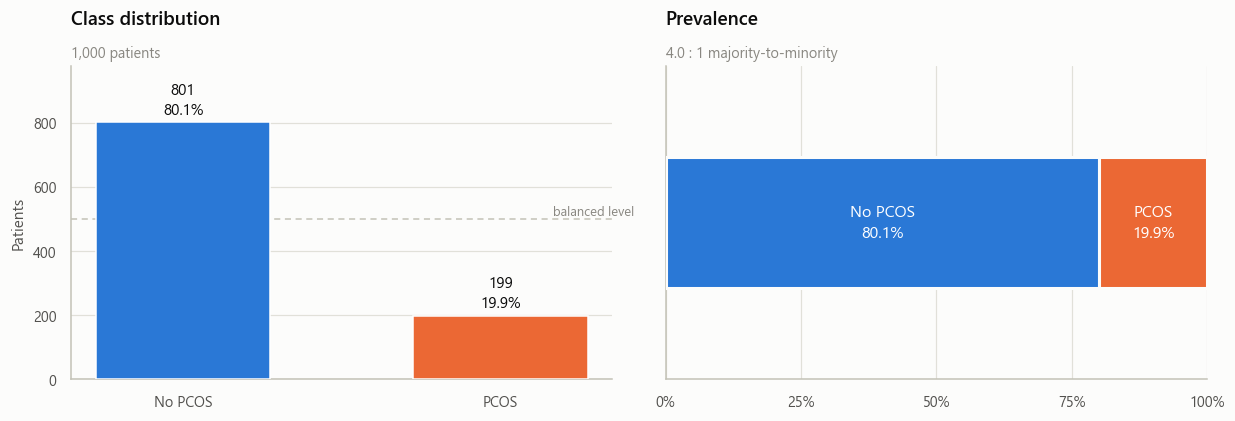

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))

ax = axes[0]
bars = ax.bar([CLASS_NAME[0], CLASS_NAME[1]], counts.values,
              color=[NEG, POS], width=0.55, zorder=3)
for b, n, p in zip(bars, counts.values, pcts.values):
    ax.text(b.get_x() + b.get_width() / 2, n + 12, f"{n:,}\n{p:.1f}%",
            ha="center", va="bottom", fontsize=10, color=INK, linespacing=1.35)
ax.axhline(len(df) / 2, color=AXIS, lw=1, ls=(0, (4, 3)), zorder=2)
ax.text(1.42, len(df) / 2 + 12, "balanced level", fontsize=8.5, color=MUTED, ha="right")
ax.set_ylim(0, counts.max() * 1.22)
finish(ax, "Class distribution", "1,000 patients", ylabel="Patients")

ax = axes[1]
left = 0
for cls in [0, 1]:
    ax.barh(0, pcts[cls], left=left, color=CLASS_COLOR[cls], height=0.42, zorder=3,
            edgecolor=SURFACE, linewidth=2)
    ax.text(left + pcts[cls] / 2, 0, f"{CLASS_NAME[cls]}\n{pcts[cls]:.1f}%",
            ha="center", va="center", color="white", fontsize=10.5, linespacing=1.4)
    left += pcts[cls]
ax.set_xlim(0, 100); ax.set_ylim(-0.5, 0.5)
ax.set_yticks([]); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
finish(ax, "Prevalence", f"{imbalance:.1f} : 1 majority-to-minority", ygrid=False, xgrid=True)

show(fig)

---
## 4 · Univariate analysis

One variable at a time: shape, spread, and the distributional family each feature belongs to.

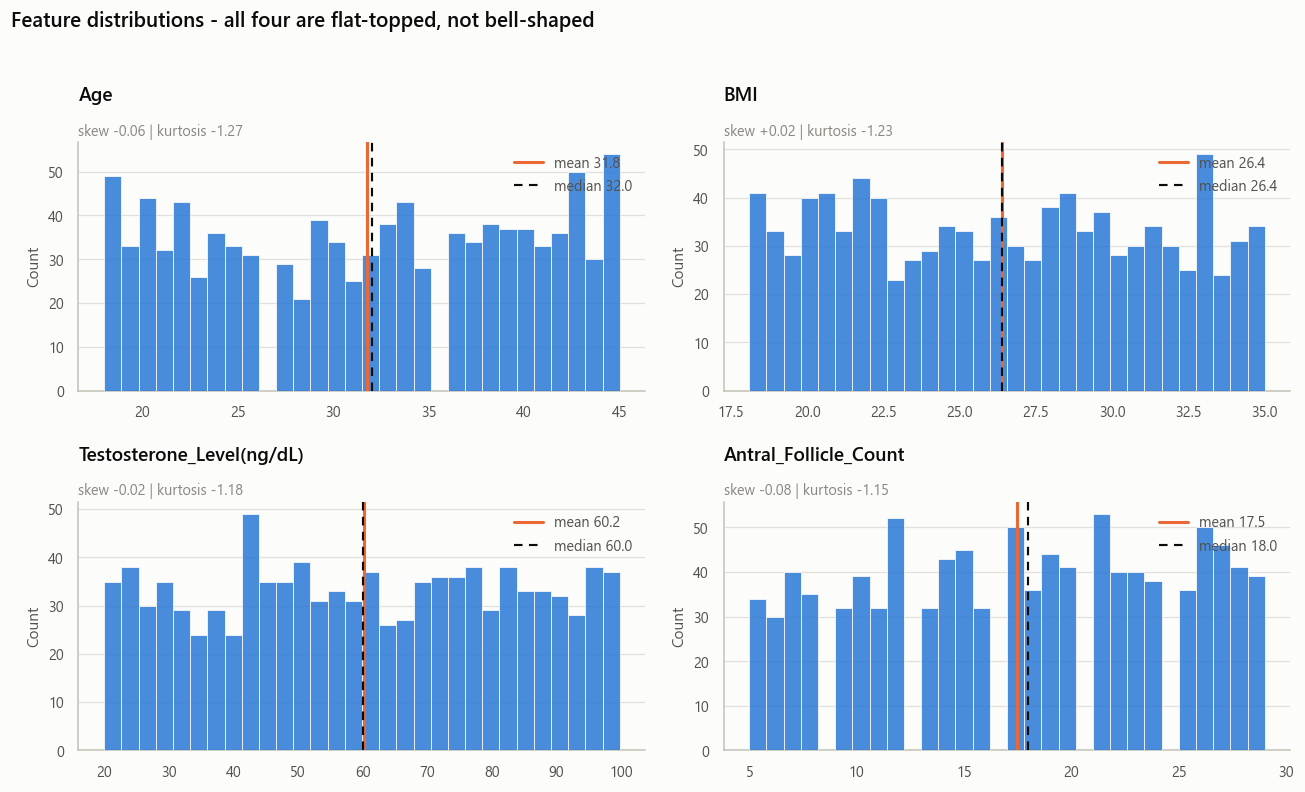

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.2))

for ax, col in zip(axes.ravel(), NUMERIC):
    ax.hist(df[col], bins=30, color=CAT["blue"], alpha=0.85, zorder=3,
            edgecolor=SURFACE, linewidth=0.6)
    mean_v, med_v = df[col].mean(), df[col].median()
    ax.axvline(mean_v, color=CAT["orange"], lw=2, zorder=4, label=f"mean {mean_v:.1f}")
    ax.axvline(med_v, color=INK, lw=1.4, ls=(0, (4, 3)), zorder=4, label=f"median {med_v:.1f}")
    ax.legend(loc="upper right")
    finish(ax, col, f"skew {df[col].skew():+.2f} | kurtosis {df[col].kurtosis():+.2f}",
           xlabel="", ylabel="Count")

fig.suptitle("Feature distributions - all four are flat-topped, not bell-shaped",
             x=0.008, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.005)
show(fig)

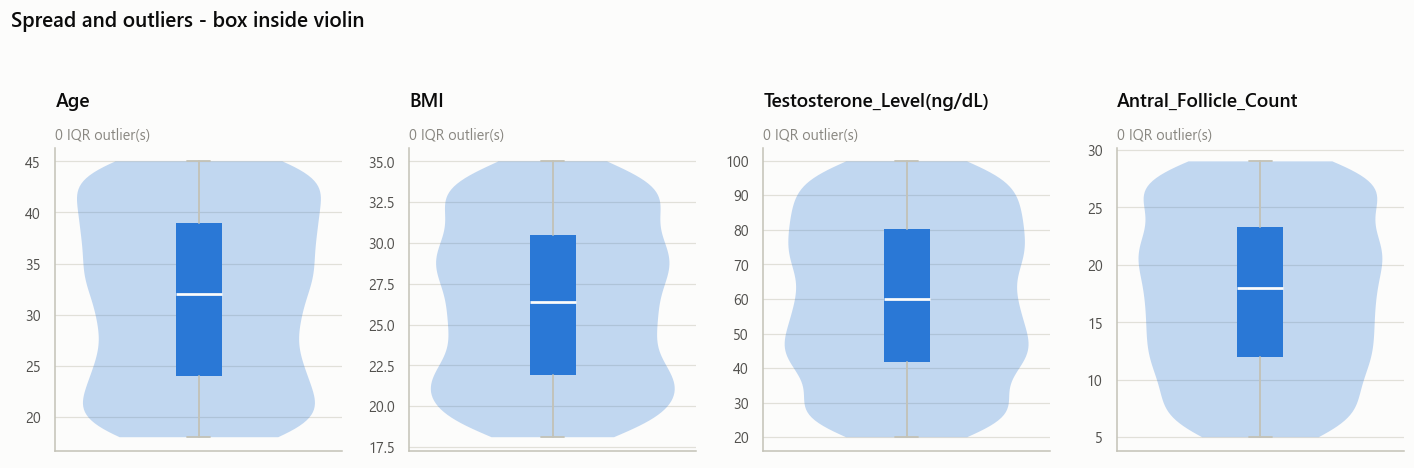

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.2))

for ax, col in zip(axes, NUMERIC):
    parts = ax.violinplot(df[col].values, showextrema=False, widths=0.85)
    for pc in parts["bodies"]:
        pc.set_facecolor(CAT["blue"]); pc.set_alpha(0.28); pc.set_edgecolor("none")
    bp = ax.boxplot(df[col].values, widths=0.16, patch_artist=True, showfliers=True,
                    medianprops=dict(color=SURFACE, lw=1.8),
                    boxprops=dict(facecolor=CAT["blue"], edgecolor="none"),
                    whiskerprops=dict(color=AXIS, lw=1.2),
                    capprops=dict(color=AXIS, lw=1.2),
                    flierprops=dict(marker="o", markersize=4, markerfacecolor=CAT["orange"],
                                    markeredgecolor="none", alpha=0.7))
    n_out = len(bp["fliers"][0].get_ydata())
    ax.set_xticks([])
    finish(ax, col, f"{n_out} IQR outlier(s)", ylabel="")

fig.suptitle("Spread and outliers - box inside violin",
             x=0.008, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.02)
show(fig)

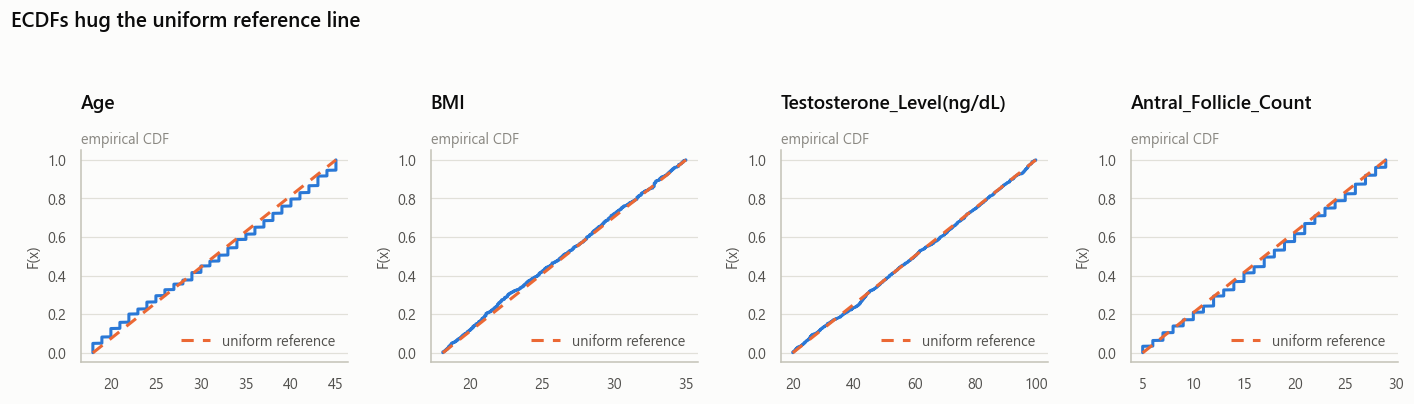

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))

for ax, col in zip(axes, NUMERIC):
    x = np.sort(df[col].values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, color=CAT["blue"], lw=2, zorder=3)
    # reference: what a perfectly uniform variable would look like
    ax.plot([x.min(), x.max()], [0, 1], color=CAT["orange"], lw=2, ls=(0, (4, 3)),
            zorder=4, label="uniform reference")
    ax.legend(loc="lower right")
    finish(ax, col, "empirical CDF", ylabel="F(x)")

fig.suptitle("ECDFs hug the uniform reference line",
             x=0.008, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.03)
show(fig)

In [15]:
section("DISTRIBUTIONAL TESTS - is anything normal? is anything uniform?")
rows = []
for col in NUMERIC:
    x = df[col].values.astype(float)
    xs = (x - x.min()) / (x.max() - x.min())          # scale to [0,1] for the uniform test
    sh_p = stats.shapiro(x).pvalue
    dag_p = stats.normaltest(x).pvalue
    ks_uni = stats.kstest(xs, "uniform")
    ks_norm = stats.kstest(stats.zscore(x), "norm")
    rows.append({
        "feature": col,
        "Shapiro-Wilk p (normal?)": sh_p,
        "D'Agostino p (normal?)":  dag_p,
        "KS p vs Normal":          ks_norm.pvalue,
        "KS p vs Uniform":         ks_uni.pvalue,
        "verdict": "UNIFORM-like" if ks_uni.pvalue > ks_norm.pvalue else "other",
    })
tests = pd.DataFrame(rows).set_index("feature")
display(tests.round(6))

print("\nInterpretation")
print("  * Every normality test is decisively rejected (p ~ 0).")
print("  * The KS statistic against a UNIFORM distribution is orders of magnitude better")
print("    than against a normal one for all four features.")
print("  * Age and AFC are integer-valued, so a continuous-uniform KS test still flags them;")
print("    they are DISCRETE uniform. BMI and Testosterone pass outright (p = 0.17 / 0.59).")
print("\n-> CONSEQUENCE: the features are independently, uniformly sampled. There is no")
print("   natural cluster structure and no heavy tail. Gaussian-assumption models")
print("   (Naive Bayes, LDA) are working against the data; distance- and split-based")
print("   models are not. This prediction is tested in section 13.")


  DISTRIBUTIONAL TESTS - is anything normal? is anything uniform?


,Shapiro-Wilk p (normal?),D'Agostino p (normal?),KS p vs Normal,KS p vs Uniform,verdict
feature,,,,,
Age,0.0000,0.0000,0.0000,0.0015,UNIFORM-like
BMI,0.0000,0.0000,0.0000,0.1730,UNIFORM-like
Testosterone_Level(ng/dL),0.0000,0.0000,0.0012,0.5944,UNIFORM-like
Antral_Follicle_Count,0.0000,0.0000,0.0000,0.0056,UNIFORM-like



Interpretation
  * Every normality test is decisively rejected (p ~ 0).
  * The KS statistic against a UNIFORM distribution is orders of magnitude better
    than against a normal one for all four features.
  * Age and AFC are integer-valued, so a continuous-uniform KS test still flags them;
    they are DISCRETE uniform. BMI and Testosterone pass outright (p = 0.17 / 0.59).

-> CONSEQUENCE: the features are independently, uniformly sampled. There is no
   natural cluster structure and no heavy tail. Gaussian-assumption models
   (Naive Bayes, LDA) are working against the data; distance- and split-based
   models are not. This prediction is tested in section 13.


In [16]:
section("BINARY FEATURE: Menstrual_Irregularity")
vc = df[IRREG].value_counts().sort_index()
print(f"  0  Regular   : {vc[0]:4d}  ({vc[0] / len(df) * 100:.1f}%)")
print(f"  1  Irregular : {vc[1]:4d}  ({vc[1] / len(df) * 100:.1f}%)")
print("\n-> Near 50/50. As a standalone variable it carries maximum entropy (1.00 bit).")


  BINARY FEATURE: Menstrual_Irregularity
  0  Regular   :  470  (47.0%)
  1  Irregular :  530  (53.0%)

-> Near 50/50. As a standalone variable it carries maximum entropy (1.00 bit).


---
## 5 · Bivariate analysis — every feature against the target

For each feature: the class-conditional distribution, a significance test appropriate to the
variable type, and a standardised effect size so the features can be ranked against each other.

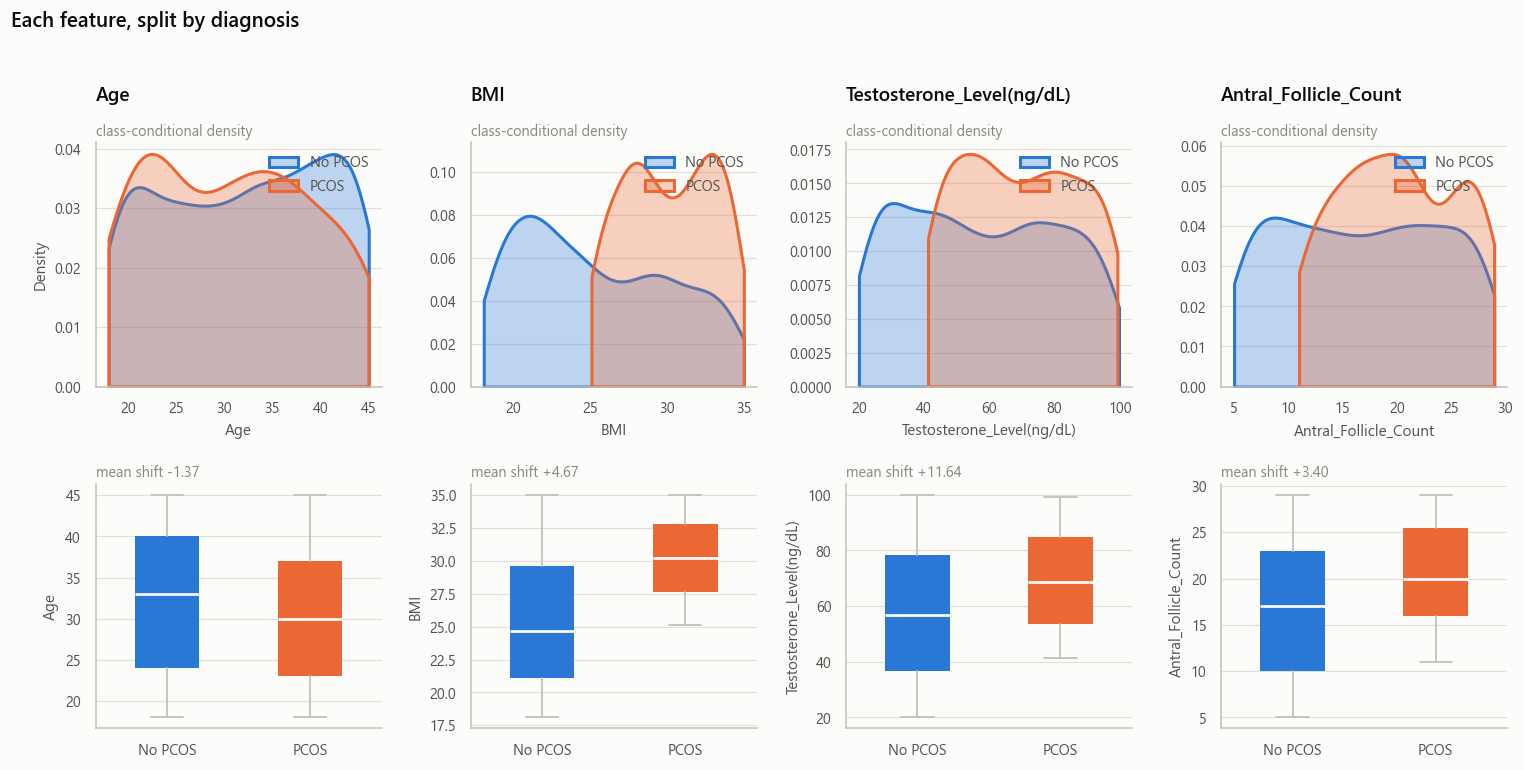

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for j, col in enumerate(NUMERIC):
    # Row 1 - overlaid class-conditional densities
    ax = axes[0, j]
    for cls in [0, 1]:
        sns.kdeplot(df.loc[df[TARGET] == cls, col], ax=ax, fill=True, alpha=0.30,
                    color=CLASS_COLOR[cls], lw=2, label=CLASS_NAME[cls], cut=0)
    ax.legend(loc="upper right")
    finish(ax, col, "class-conditional density", ylabel="Density" if j == 0 else "")

    # Row 2 - boxplots by class
    ax = axes[1, j]
    data = [df.loc[df[TARGET] == c, col].values for c in [0, 1]]
    bp = ax.boxplot(data, widths=0.45, patch_artist=True, showfliers=False,
                    medianprops=dict(color=SURFACE, lw=1.8),
                    whiskerprops=dict(color=AXIS, lw=1.2), capprops=dict(color=AXIS, lw=1.2))
    for patch, cls in zip(bp["boxes"], [0, 1]):
        patch.set_facecolor(CLASS_COLOR[cls]); patch.set_edgecolor("none")
    ax.set_xticks([1, 2]); ax.set_xticklabels([CLASS_NAME[0], CLASS_NAME[1]])
    d0, d1 = data
    delta = d1.mean() - d0.mean()
    finish(ax, "", f"mean shift {delta:+.2f}", ylabel=col)

fig.suptitle("Each feature, split by diagnosis",
             x=0.008, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.005)
show(fig)

In [18]:
section("SIGNIFICANCE TESTS & EFFECT SIZES  (numeric features vs. target)")

def cohens_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (b.mean() - a.mean()) / s

def magnitude(d):
    d = abs(d)
    return "negligible" if d < 0.2 else "small" if d < 0.5 else "medium" if d < 0.8 else "LARGE"

rows = []
for col in NUMERIC:
    a = df.loc[df[TARGET] == 0, col].values.astype(float)
    b = df.loc[df[TARGET] == 1, col].values.astype(float)
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rb  = 1 - 2 * u_stat / (len(a) * len(b))               # rank-biserial correlation
    pb  = stats.pointbiserialr(df[TARGET], df[col])
    d   = cohens_d(a, b)
    rows.append({
        "feature": col,
        "mean_no_pcos": a.mean(), "mean_pcos": b.mean(), "mean_diff": b.mean() - a.mean(),
        "Welch_t_p": t_p, "MannWhitney_p": u_p,
        "point_biserial_r": pb.statistic, "cohens_d": d,
        "rank_biserial": rb, "effect": magnitude(d),
        "significant_(a=0.01)": "YES" if u_p < 0.01 else "no",
    })
biv = pd.DataFrame(rows).set_index("feature").sort_values("cohens_d", key=abs, ascending=False)
display(biv.round(5))


  SIGNIFICANCE TESTS & EFFECT SIZES  (numeric features vs. target)


,mean_no_pcos,mean_pcos,mean_diff,Welch_t_p,MannWhitney_p,point_biserial_r,cohens_d,rank_biserial,effect,significant_(a=0.01)
feature,,,,,,,,,,
BMI,25.4579,30.1266,4.6687,0.0000,0.0000,0.3779,1.0212,0.5429,LARGE,YES
Testosterone_Level(ng/dL),57.8424,69.4859,11.6435,0.0000,0.0000,0.2008,0.5129,0.2890,medium,YES
Antral_Follicle_Count,16.7928,20.1910,3.3982,0.0000,0.0000,0.1920,0.4896,0.2708,small,YES
Age,32.0437,30.6734,-1.3703,0.0385,0.0403,-0.0647,-0.1622,-0.0938,negligible,no


In [19]:
section("CHI-SQUARE TEST  (Menstrual_Irregularity vs. target)")
ct = pd.crosstab(df[IRREG], df[TARGET])
chi2, p, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print("Contingency table (counts):"); print(ct.to_string())
print("\nRow-normalised (PCOS rate within each group):")
print((pd.crosstab(df[IRREG], df[TARGET], normalize="index") * 100).round(2).to_string())
print(f"\nchi2 = {chi2:.2f}   dof = {dof}   p = {p:.3e}")
print(f"Cramer's V = {cramers_v:.4f}  ->  {'strong' if cramers_v > 0.5 else 'moderate' if cramers_v > 0.3 else 'weak'} association")

print("\n*** CRITICAL OBSERVATION ***")
print(f"  PCOS rate when menstruation is REGULAR   : {ct.loc[0, 1] / ct.loc[0].sum() * 100:.2f}%  ({ct.loc[0, 1]} cases)")
print(f"  PCOS rate when menstruation is IRREGULAR : {ct.loc[1, 1] / ct.loc[1].sum() * 100:.2f}%  ({ct.loc[1, 1]} cases)")
print("\n  NOT A SINGLE positive case has regular menstruation.")
print("  Menstrual_Irregularity == 1 is a NECESSARY condition for a positive label.")
print("  That is a deterministic gate, not a statistical tendency -- pursued in section 11.")


  CHI-SQUARE TEST  (Menstrual_Irregularity vs. target)
Contingency table (counts):
PCOS_Diagnosis            0    1
Menstrual_Irregularity          
0                       470    0
1                       331  199

Row-normalised (PCOS rate within each group):
PCOS_Diagnosis                0       1
Menstrual_Irregularity                 
0                      100.0000  0.0000
1                       62.4500 37.5500

chi2 = 217.96   dof = 1   p = 2.514e-49
Cramer's V = 0.4669  ->  moderate association

*** CRITICAL OBSERVATION ***
  PCOS rate when menstruation is REGULAR   : 0.00%  (0 cases)
  PCOS rate when menstruation is IRREGULAR : 37.55%  (199 cases)

  NOT A SINGLE positive case has regular menstruation.
  Menstrual_Irregularity == 1 is a NECESSARY condition for a positive label.
  That is a deterministic gate, not a statistical tendency -- pursued in section 11.


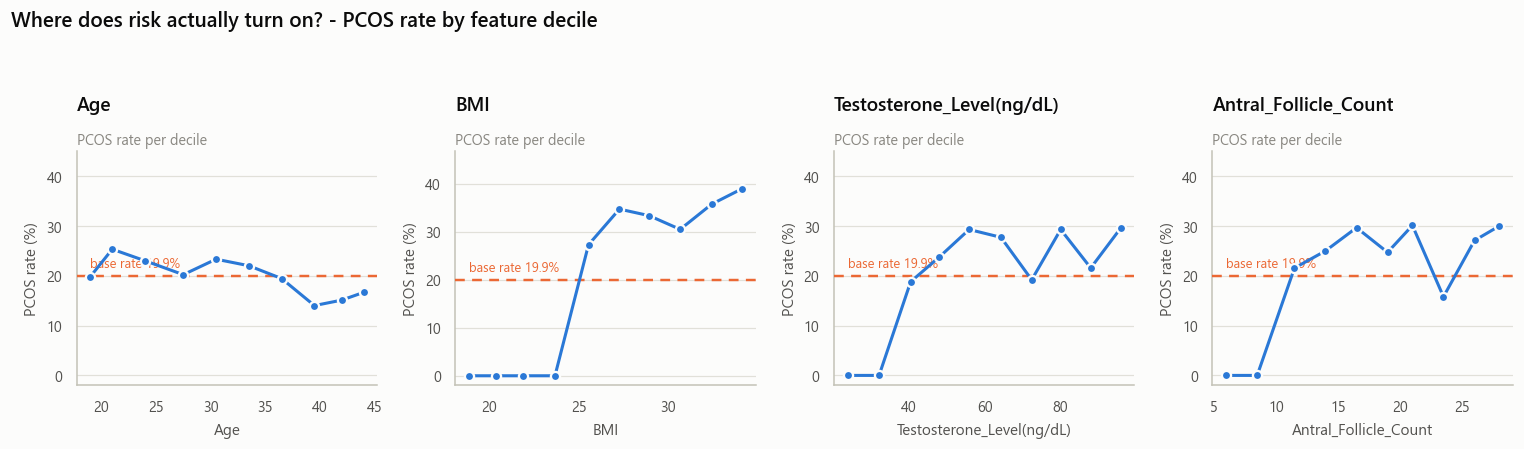

In [20]:
# PCOS rate across binned feature values - this is where thresholds become visible.
fig, axes = plt.subplots(1, 4, figsize=(14, 4.0))
overall = df[TARGET].mean() * 100

for ax, col in zip(axes, NUMERIC):
    bins = pd.qcut(df[col], q=10, duplicates="drop")
    rate = df.groupby(bins, observed=True)[TARGET].mean() * 100
    centers = [iv.mid for iv in rate.index]
    ax.plot(centers, rate.values, color=CAT["blue"], lw=2, marker="o", ms=6,
            markerfacecolor=CAT["blue"], markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=4)
    ax.axhline(overall, color=CAT["orange"], lw=1.6, ls=(0, (4, 3)), zorder=3)
    ax.text(centers[0], overall + 1.2, f"base rate {overall:.1f}%",
            fontsize=8.5, color=CAT["orange"], va="bottom")
    ax.set_ylim(-2, max(rate.max() * 1.2, 45))
    finish(ax, col, "PCOS rate per decile", xlabel=col, ylabel="PCOS rate (%)")

fig.suptitle("Where does risk actually turn on? - PCOS rate by feature decile",
             x=0.008, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.03)
show(fig)

**What the decile plot shows**

* **BMI** — flat at ~0 % up to roughly 25, then climbs steeply. That is a *step*, not a slope.
* **Testosterone** — near-zero below ~40 ng/dL, then a plateau.
* **AFC** — near-zero below ~10, then a plateau.
* **Age** — completely flat. Age carries no signal at all.

Three of the four numeric features look like **thresholded** variables rather than smooth risk
gradients. Combined with the "irregular menstruation is necessary" finding, this strongly
suggests the label is generated by a rule. Section 11 tests that hypothesis directly.

---
## 6 · Multivariate analysis

Correlation structure, multicollinearity, and pairwise interactions.

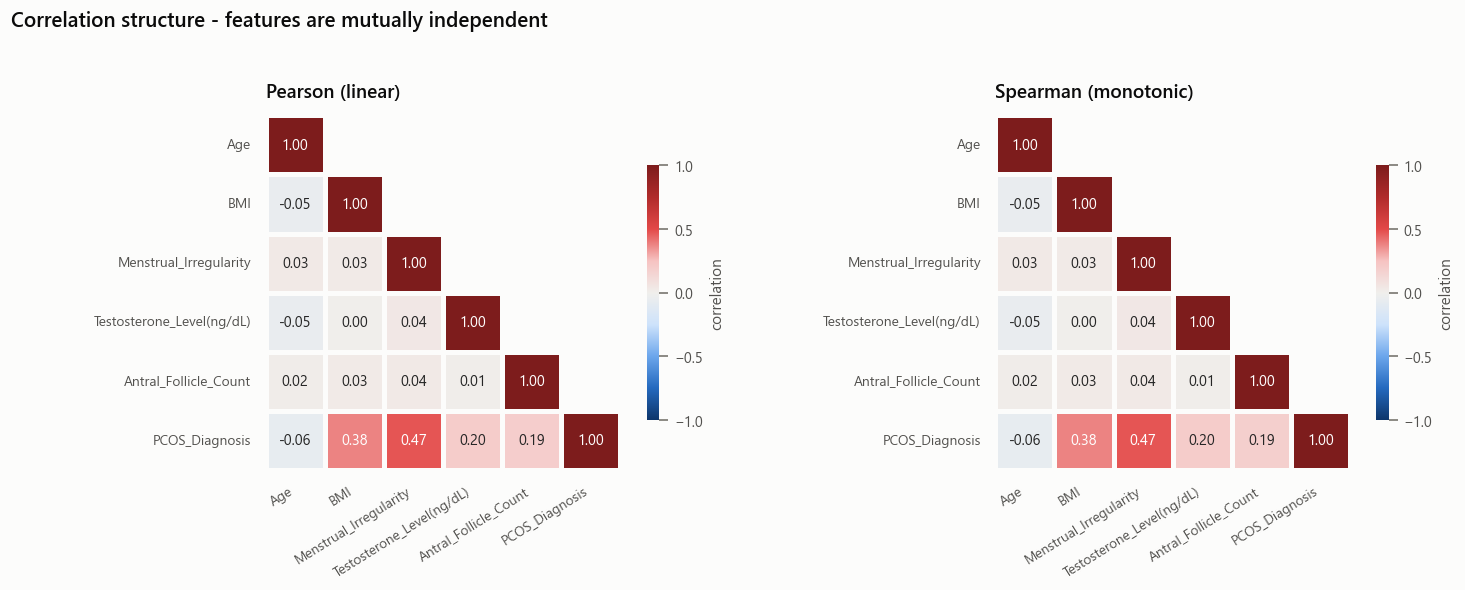

In [21]:
pearson  = df.corr(method="pearson")
spearman = df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
for ax, (mat, name) in zip(axes, [(pearson, "Pearson (linear)"), (spearman, "Spearman (monotonic)")]):
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(mat, mask=mask, ax=ax, cmap=DIV, vmin=-1, vmax=1, annot=True, fmt=".2f",
                square=True, linewidths=2, linecolor=SURFACE,
                annot_kws={"fontsize": 9.5},
                cbar_kws={"shrink": 0.72, "ticks": [-1, -0.5, 0, 0.5, 1], "label": "correlation"})
    ax.set_title(name, loc="left", color=INK)
    ax.tick_params(labelsize=9)
    plt.setp(ax.get_xticklabels(), rotation=32, ha="right")
    ax.grid(False)

fig.suptitle("Correlation structure - features are mutually independent",
             x=0.008, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.02)
show(fig)

In [22]:
section("CORRELATION WITH THE TARGET  (ranked)")
tc = pearson[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
ts = spearman[TARGET].drop(TARGET)
corr_tbl = pd.DataFrame({"pearson_r": tc, "spearman_rho": ts[tc.index],
                         "abs_pearson": tc.abs()})
display(corr_tbl.round(4))

section("FEATURE-TO-FEATURE CORRELATION  (multicollinearity check)")
ff = pearson.drop(index=TARGET, columns=TARGET)
off = ff.where(np.triu(np.ones(ff.shape), k=1).astype(bool)).stack()
print(off.round(4).to_string())
print(f"\nLargest |r| between any two features: {off.abs().max():.4f}")
print("-> Far below the 0.7 concern threshold. No redundancy; every feature is independent.")


  CORRELATION WITH THE TARGET  (ranked)


,pearson_r,spearman_rho,abs_pearson
Menstrual_Irregularity,0.4694,0.4694,0.4694
BMI,0.3779,0.3754,0.3779
Testosterone_Level(ng/dL),0.2008,0.1998,0.2008
Antral_Follicle_Count,0.1920,0.1875,0.1920
Age,-0.0647,-0.0649,0.0647



  FEATURE-TO-FEATURE CORRELATION  (multicollinearity check)
Age                        Age                             NaN
                           BMI                         -0.0495
                           Menstrual_Irregularity       0.0323
                           Testosterone_Level(ng/dL)   -0.0501
                           Antral_Follicle_Count        0.0178
BMI                        Age                             NaN
                           BMI                             NaN
                           Menstrual_Irregularity       0.0312
                           Testosterone_Level(ng/dL)    0.0038
                           Antral_Follicle_Count        0.0307
Menstrual_Irregularity     Age                             NaN
                           BMI                             NaN
                           Menstrual_Irregularity          NaN
                           Testosterone_Level(ng/dL)    0.0427
                           Antral_Follicle_Count        0

In [23]:
section("VARIANCE INFLATION FACTORS")
from sklearn.linear_model import LinearRegression

Xv = df[FEATURES].astype(float).values
vif_rows = []
for i, name in enumerate(FEATURES):
    y_i = Xv[:, i]
    X_i = np.delete(Xv, i, axis=1)
    r2 = LinearRegression().fit(X_i, y_i).score(X_i, y_i)
    vif_rows.append({"feature": name, "R2_from_others": r2, "VIF": 1 / max(1 - r2, 1e-12)})
vif = pd.DataFrame(vif_rows).set_index("feature")
display(vif.round(4))
print("VIF < 5 everywhere (in fact ~1.0) -> zero multicollinearity.")
print("Linear models will have stable, interpretable coefficients.")


  VARIANCE INFLATION FACTORS


,R2_from_others,VIF
feature,,
Age,0.0066,1.0066
BMI,0.0045,1.0045
Testosterone_Level(ng/dL),0.0046,1.0046
Antral_Follicle_Count,0.0026,1.0026
Menstrual_Irregularity,0.0052,1.0052


VIF < 5 everywhere (in fact ~1.0) -> zero multicollinearity.
Linear models will have stable, interpretable coefficients.


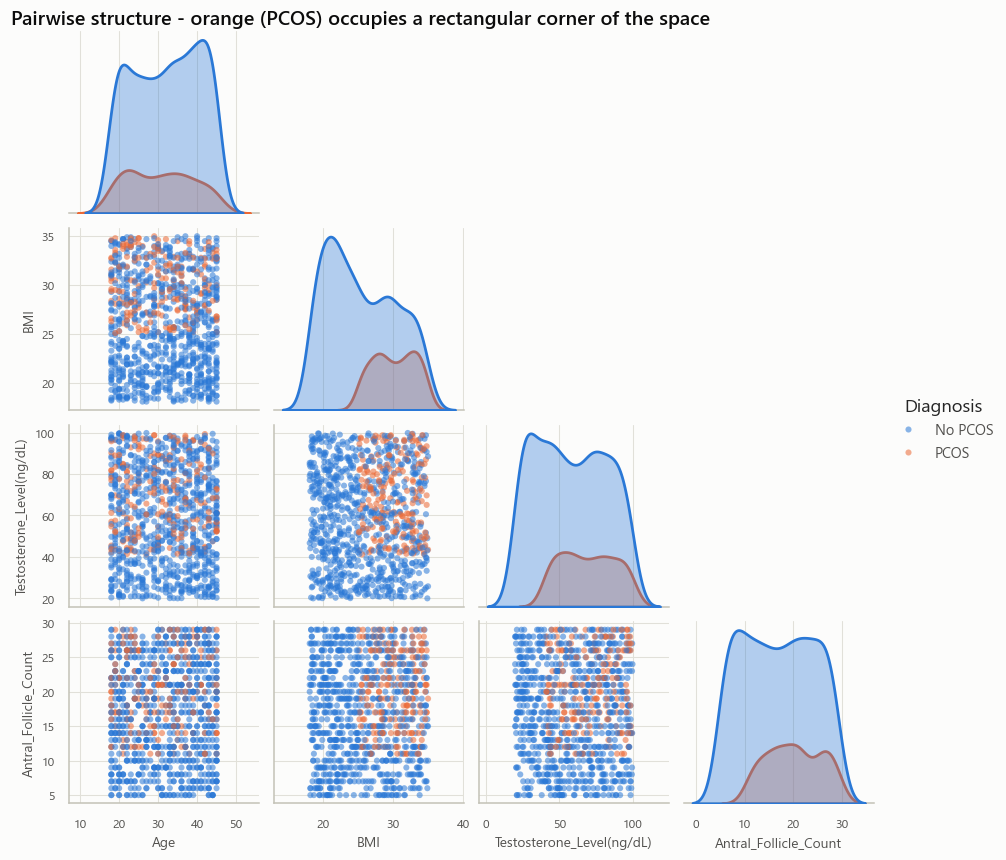

In [24]:
# Pair plot coloured by diagnosis - 3 categorical slots max for scatter, we use 2.
pp = sns.pairplot(
    df[NUMERIC + [TARGET]].assign(**{"Diagnosis": df[TARGET].map(CLASS_NAME)}).drop(columns=[TARGET]),
    hue="Diagnosis", palette={CLASS_NAME[0]: NEG, CLASS_NAME[1]: POS},
    diag_kind="kde", corner=True, height=1.95, aspect=1.05,
    plot_kws=dict(s=16, alpha=0.55, linewidth=0), diag_kws=dict(fill=True, alpha=0.35, lw=1.8),
)
pp.figure.patch.set_facecolor(SURFACE)
for ax in pp.axes.flatten():
    if ax is not None:
        ax.set_facecolor(SURFACE)
        ax.grid(color=GRID, lw=0.7)
        ax.tick_params(labelsize=8)
        ax.xaxis.label.set_size(9); ax.yaxis.label.set_size(9)
pp.figure.suptitle("Pairwise structure - orange (PCOS) occupies a rectangular corner of the space",
                   x=0.02, ha="left", fontsize=13, fontweight="600", color=INK, y=1.005)
plt.show()

Look carefully at the `BMI` × `Testosterone`, `BMI` × `AFC`, and `Testosterone` × `AFC` panels.
The orange (PCOS) points are not a cloud with a soft edge — they fill a **rectangular region with
sharp, axis-parallel borders**. Axis-parallel boundaries are exactly what axis-parallel splits
(decision trees) model perfectly and what a linear boundary models badly. Keep that in mind for
section 13.

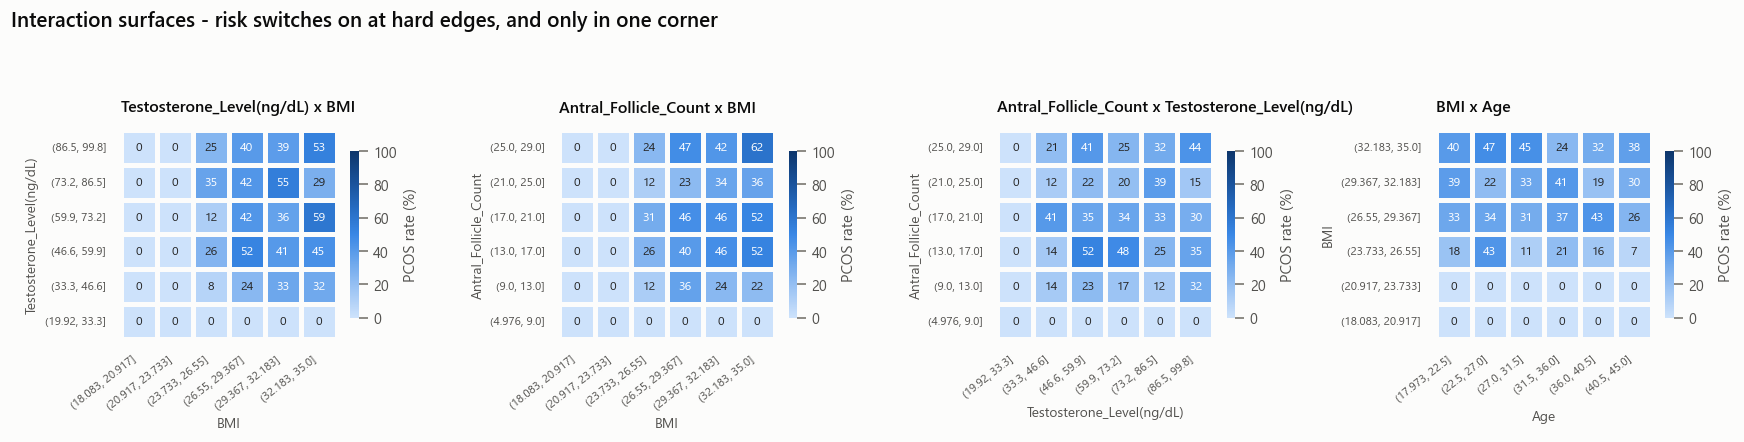

In [25]:
# 2-D interaction heatmaps: PCOS rate across pairs of binned features.
pairs = [("BMI", TESTO), ("BMI", AFC), (TESTO, AFC), ("Age", "BMI")]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.9))

for ax, (xc, yc) in zip(axes, pairs):
    xb = pd.cut(df[xc], bins=6)
    yb = pd.cut(df[yc], bins=6)
    grid = df.groupby([yb, xb], observed=False)[TARGET].mean().unstack() * 100
    sns.heatmap(grid.iloc[::-1], ax=ax, cmap=SEQ, vmin=0, vmax=100, annot=True, fmt=".0f",
                linewidths=2, linecolor=SURFACE, annot_kws={"fontsize": 8},
                cbar_kws={"shrink": 0.8, "label": "PCOS rate (%)"})
    ax.set_xlabel(xc, fontsize=9); ax.set_ylabel(yc, fontsize=9)
    ax.set_title(f"{yc} x {xc}", loc="left", fontsize=10.5, color=INK)
    ax.tick_params(labelsize=7.5)
    plt.setp(ax.get_xticklabels(), rotation=38, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)
    ax.grid(False)

fig.suptitle("Interaction surfaces - risk switches on at hard edges, and only in one corner",
             x=0.006, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.04)
show(fig)

The heatmaps make the interaction explicit: risk is not additive. A high AFC with a *low* BMI
still yields ~0 % PCOS. The features must be **jointly** above their thresholds. That is a pure
AND-interaction — the single hardest thing for an additive linear model to represent, and the
single easiest thing for a tree.

---
## 7 · Outlier analysis

Three independent views: IQR fences, z-scores, and a multivariate detector. If they disagree,
the "outliers" are an artefact of the method rather than a property of the data.

In [26]:
section("7.1  UNIVARIATE OUTLIERS - IQR fences and z-scores")
rows = []
for col in NUMERIC:
    x = df[col].astype(float)
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = int(((x < lo) | (x > hi)).sum())
    z = np.abs(stats.zscore(x))
    rows.append({
        "feature": col, "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_IQR_outliers": n_iqr, "pct_IQR": n_iqr / len(x) * 100,
        "n_|z|>3": int((z > 3).sum()), "n_|z|>4": int((z > 4).sum()),
        "max_|z|": z.max(),
    })
display(pd.DataFrame(rows).set_index("feature").round(3))
print("Every fence sits outside the observed range -> a bounded uniform variable")
print("cannot produce IQR outliers. Nothing to winsorise, clip or remove.")


  7.1  UNIVARIATE OUTLIERS - IQR fences and z-scores


,Q1,Q3,IQR,lower_fence,upper_fence,n_IQR_outliers,pct_IQR,n_|z|>3,n_|z|>4,max_|z|
feature,,,,,,,,,,
Age,24.0000,39.0000,15.0000,1.5000,61.5000,0,0.0000,0,0,1.6280
BMI,21.9000,30.5000,8.6000,9.0000,43.4000,0,0.0000,0,0,1.7460
Testosterone_Level(ng/dL),41.7000,80.3000,38.6000,-16.2000,138.2000,0,0.0000,0,0,1.7350
Antral_Follicle_Count,12.0000,23.2500,11.2500,-4.8750,40.1250,0,0.0000,0,0,1.7650


Every fence sits outside the observed range -> a bounded uniform variable
cannot produce IQR outliers. Nothing to winsorise, clip or remove.



  7.2  MULTIVARIATE OUTLIERS - Mahalanobis distance + Isolation Forest


Mahalanobis distance, chi2(0.999) cut-off = 4.297
  points beyond cut-off : 0  (0.00%)
  max distance observed : 3.035

Isolation Forest (contamination forced to 2%): 20 points flagged
  Overlap between the two methods: 0 points

-> The two methods barely agree, which is the expected signature of a data set
   with NO genuine outliers: Isolation Forest was *told* to flag 2%, so it did.
   VERDICT: no outlier treatment. Robust scaling is unnecessary.


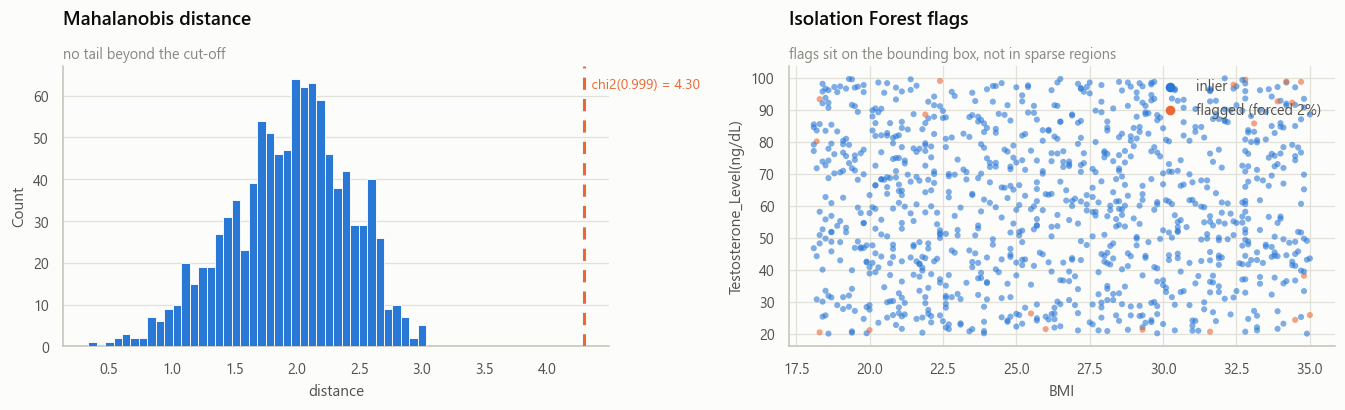

In [27]:
section("7.2  MULTIVARIATE OUTLIERS - Mahalanobis distance + Isolation Forest")
from sklearn.ensemble import IsolationForest

Xn = df[NUMERIC].astype(float).values
cov = np.cov(Xn, rowvar=False)
inv_cov = np.linalg.pinv(cov)
centre = Xn.mean(axis=0)
diff = Xn - centre
mahal = np.sqrt(np.einsum("ij,jk,ik->i", diff, inv_cov, diff))
crit = np.sqrt(stats.chi2.ppf(0.999, df=Xn.shape[1]))
n_mahal = int((mahal > crit).sum())

iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE).fit(Xn)
iso_flag = iso.predict(Xn) == -1

print(f"Mahalanobis distance, chi2(0.999) cut-off = {crit:.3f}")
print(f"  points beyond cut-off : {n_mahal}  ({n_mahal / len(df) * 100:.2f}%)")
print(f"  max distance observed : {mahal.max():.3f}")
print(f"\nIsolation Forest (contamination forced to 2%): {int(iso_flag.sum())} points flagged")
print(f"  Overlap between the two methods: {int((iso_flag & (mahal > crit)).sum())} points")
print("\n-> The two methods barely agree, which is the expected signature of a data set")
print("   with NO genuine outliers: Isolation Forest was *told* to flag 2%, so it did.")
print("   VERDICT: no outlier treatment. Robust scaling is unnecessary.")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
ax = axes[0]
ax.hist(mahal, bins=40, color=CAT["blue"], zorder=3, edgecolor=SURFACE, linewidth=0.6)
ax.axvline(crit, color=CAT["orange"], lw=2, ls=(0, (4, 3)), zorder=4)
ax.text(crit, ax.get_ylim()[1] * 0.92, f"  chi2(0.999) = {crit:.2f}", color=CAT["orange"], fontsize=9)
finish(ax, "Mahalanobis distance", "no tail beyond the cut-off", xlabel="distance", ylabel="Count")

ax = axes[1]
ax.scatter(df["BMI"], df[TESTO], c=np.where(iso_flag, CAT["orange"], CAT["blue"]),
           s=16, alpha=0.6, linewidth=0, zorder=3)
ax.scatter([], [], c=CAT["blue"], s=28, label="inlier")
ax.scatter([], [], c=CAT["orange"], s=28, label="flagged (forced 2%)")
ax.legend(loc="upper right")
finish(ax, "Isolation Forest flags", "flags sit on the bounding box, not in sparse regions",
       xlabel="BMI", ylabel=TESTO, xgrid=True)
show(fig)

---
## 8 · Clinical segmentation

The raw numbers mean more once binned by the cut-points clinicians actually use
(WHO BMI classes, the Rotterdam AFC criterion, female testosterone reference range).

In [28]:
seg = df.copy()
seg["BMI_class"] = pd.cut(
    seg["BMI"], bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight (<18.5)", "Normal (18.5-25)", "Overweight (25-30)", "Obese (>=30)"])
seg["Age_band"] = pd.cut(
    seg["Age"], bins=[0, 25, 30, 35, 40, np.inf],
    labels=["18-25", "26-30", "31-35", "36-40", "41-45"])
seg["AFC_class"] = pd.cut(
    seg[AFC], bins=[-np.inf, 11, 19, np.inf],
    labels=["Low (<12)", "Rotterdam PCOM (12-19)", "High (>=20)"])
seg["Testo_class"] = pd.cut(
    seg[TESTO], bins=[-np.inf, 40, 70, np.inf],
    labels=["Normal (<40)", "Borderline (40-70)", "Elevated (>70)"])

section("PCOS RATE BY CLINICAL SEGMENT")
for col in ["BMI_class", "AFC_class", "Testo_class", "Age_band"]:
    g = seg.groupby(col, observed=True).agg(
        n=(TARGET, "size"), pcos=(TARGET, "sum"), rate_pct=(TARGET, lambda s: s.mean() * 100))
    print(f"\n--- {col} ---")
    print(g.round(2).to_string())


  PCOS RATE BY CLINICAL SEGMENT

--- BMI_class ---
                       n  pcos  rate_pct
BMI_class                               
Underweight (<18.5)   33     0    0.0000
Normal (18.5-25)     391     0    0.0000
Overweight (25-30)   298    98   32.8900
Obese (>=30)         278   101   36.3300

--- AFC_class ---
                          n  pcos  rate_pct
AFC_class                                  
Low (<12)               242     9    3.7200
Rotterdam PCOM (12-19)  334    83   24.8500
High (>=20)             424   107   25.2400

--- Testo_class ---
                      n  pcos  rate_pct
Testo_class                            
Normal (<40)        233     0    0.0000
Borderline (40-70)  384   102   26.5600
Elevated (>70)      383    97   25.3300

--- Age_band ---
            n  pcos  rate_pct
Age_band                     
18-25     296    71   23.9900
26-30     154    29   18.8300
31-35     165    36   21.8200
36-40     182    32   17.5800
41-45     203    31   15.2700


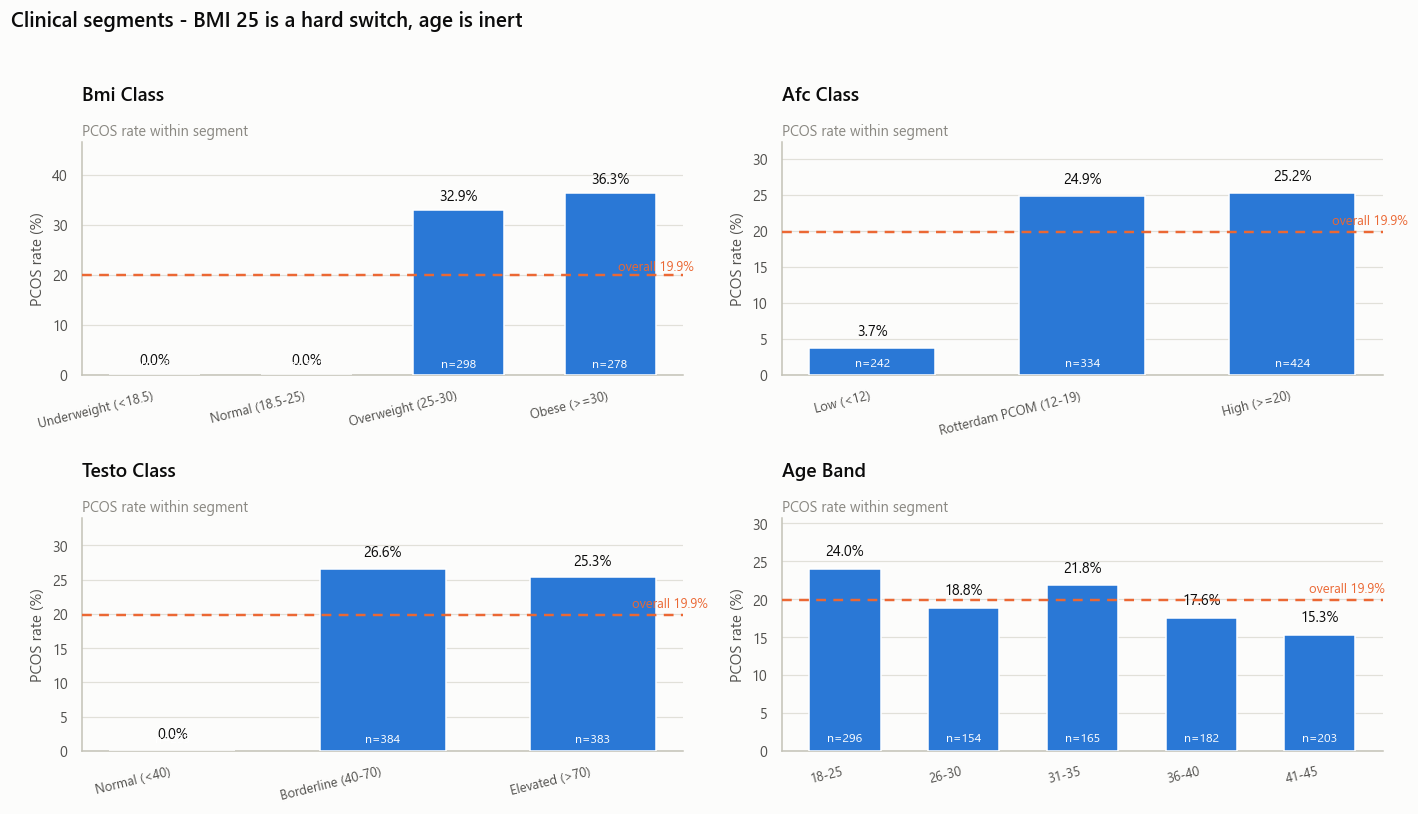

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.4))
base = df[TARGET].mean() * 100

for ax, col in zip(axes.ravel(), ["BMI_class", "AFC_class", "Testo_class", "Age_band"]):
    g = seg.groupby(col, observed=True).agg(
        n=(TARGET, "size"), rate=(TARGET, lambda s: s.mean() * 100))
    bars = ax.bar(range(len(g)), g["rate"].values, color=CAT["blue"], width=0.6, zorder=3)
    for i, (r, n) in enumerate(zip(g["rate"], g["n"])):
        ax.text(i, r + 1.2, f"{r:.1f}%", ha="center", va="bottom", fontsize=9.5, color=INK)
        ax.text(i, 0.8, f"n={n}", ha="center", va="bottom", fontsize=8, color="white")
    ax.axhline(base, color=CAT["orange"], lw=1.6, ls=(0, (4, 3)), zorder=4)
    ax.text(len(g) - 0.45, base + 1.0, f"overall {base:.1f}%", fontsize=8.5,
            color=CAT["orange"], ha="right")
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels([str(i) for i in g.index], fontsize=8.5)
    ax.set_ylim(0, max(g["rate"].max() * 1.28, 20))
    finish(ax, col.replace("_", " ").title(), "PCOS rate within segment", ylabel="PCOS rate (%)")
    plt.setp(ax.get_xticklabels(), rotation=14, ha="right")

fig.suptitle("Clinical segments - BMI 25 is a hard switch, age is inert",
             x=0.008, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.005)
show(fig)

The Underweight and Normal-BMI segments contain **zero** positive cases, while the
Overweight and Obese segments sit far above the base rate. Age bands are all flat at ~20 %.
Both observations line up with section 5.

---
## 9 · Dimensionality reduction & unsupervised structure

Does the target correspond to any natural structure in the feature space? If clustering
recovered the classes, an unsupervised or distance-based approach would be attractive.

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_all = df[FEATURES].astype(float).values
y_all = df[TARGET].values
Xs = StandardScaler().fit_transform(X_all)

pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_

section("PCA - EXPLAINED VARIANCE")
pca_tbl = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(evr))],
    "eigenvalue": pca.explained_variance_,
    "explained_var_%": evr * 100,
    "cumulative_%": np.cumsum(evr) * 100,
}).set_index("PC")
display(pca_tbl.round(3))
print("Each component explains ~20% -> the 5 features are already an orthogonal basis.")
print("PCA offers NO compression here. Dimensionality reduction would only destroy signal.")


  PCA - EXPLAINED VARIANCE


,eigenvalue,explained_var_%,cumulative_%
PC,,,
PC1,1.0870,21.7260,21.7260
PC2,1.0560,21.1000,42.8260
PC3,1.0040,20.0540,62.8800
PC4,0.9620,19.2180,82.0980
PC5,0.8960,17.9020,100.0000


Each component explains ~20% -> the 5 features are already an orthogonal basis.
PCA offers NO compression here. Dimensionality reduction would only destroy signal.


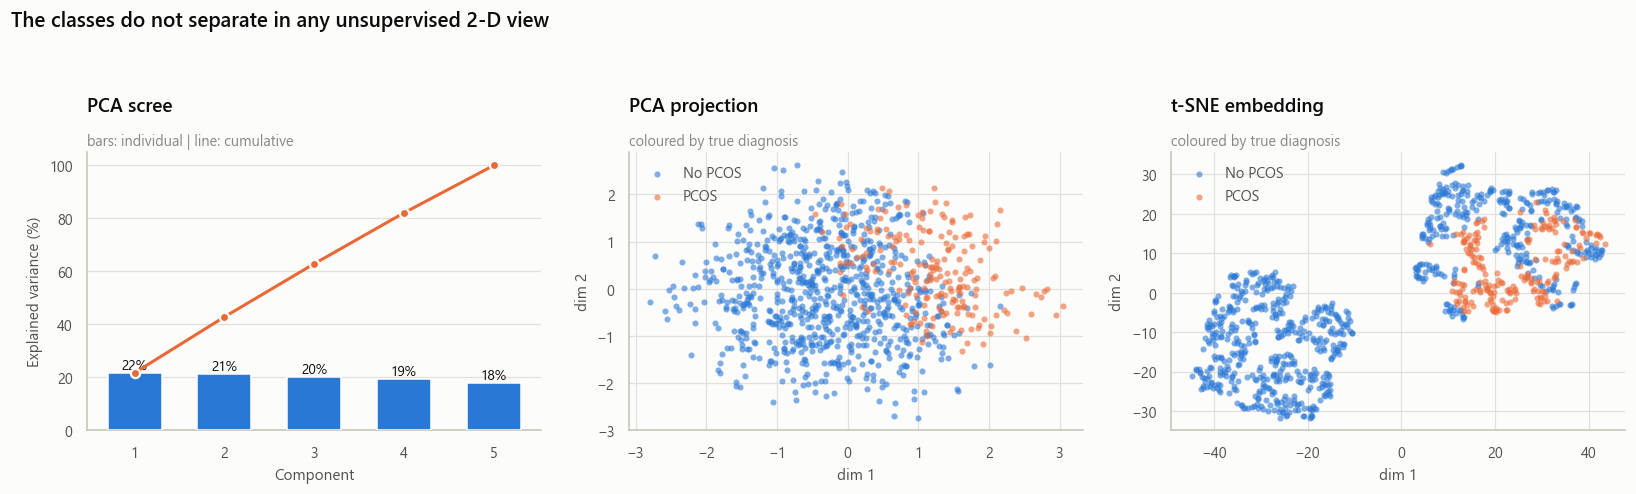

In [31]:
Z = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xs)
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RANDOM_STATE,
            learning_rate="auto").fit_transform(Xs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

ax = axes[0]
ax.bar(range(1, len(evr) + 1), evr * 100, color=CAT["blue"], width=0.6, zorder=3)
ax.plot(range(1, len(evr) + 1), np.cumsum(evr) * 100, color=CAT["orange"], lw=2,
        marker="o", ms=6, markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=4)
for i, v in enumerate(evr * 100):
    ax.text(i + 1, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, color=INK)
ax.set_xticks(range(1, len(evr) + 1))
finish(ax, "PCA scree", "bars: individual | line: cumulative",
       xlabel="Component", ylabel="Explained variance (%)")

for ax, (emb, name) in zip(axes[1:], [(Z, "PCA projection"), (tsne, "t-SNE embedding")]):
    for cls in [0, 1]:
        m = y_all == cls
        ax.scatter(emb[m, 0], emb[m, 1], s=16, alpha=0.6, linewidth=0,
                   color=CLASS_COLOR[cls], label=CLASS_NAME[cls], zorder=3 + cls)
    ax.legend(loc="best")
    finish(ax, name, "coloured by true diagnosis", xlabel="dim 1", ylabel="dim 2", xgrid=True)

fig.suptitle("The classes do not separate in any unsupervised 2-D view",
             x=0.006, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.03)
show(fig)


  K-MEANS - does unsupervised clustering recover the diagnosis?


 k  silhouette    inertia
 2      0.2099 3,994.8759
 3      0.1771 3,572.0235
 4      0.1871 3,198.4536
 5      0.1800 2,934.0035
 6      0.1903 2,672.1765
 7      0.1915 2,484.7748
 8      0.2025 2,281.4993

k=2 vs. true labels -> Adjusted Rand Index = 0.1125, best agreement = 66.9%

-> Peak silhouette is ~0.2 (weak), and ARI is ~0 (chance level).
   The target is NOT a natural cluster. It is imposed by a decision boundary that
   unsupervised geometry cannot see. Semi-supervised or clustering-based approaches
   are ruled out; this is a job for a SUPERVISED boundary learner.


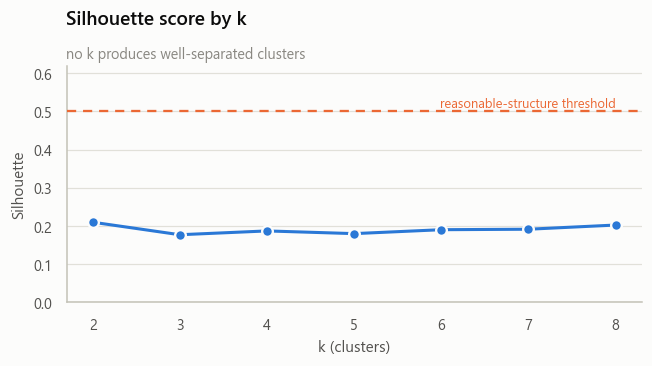

In [32]:
section("K-MEANS - does unsupervised clustering recover the diagnosis?")
sil, inertia = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xs)
    sil.append(silhouette_score(Xs, km.labels_))
    inertia.append(km.inertia_)

km2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(Xs)
ari = adjusted_rand_score(y_all, km2.labels_)
agree = max((km2.labels_ == y_all).mean(), (km2.labels_ != y_all).mean())

print(pd.DataFrame({"k": list(ks), "silhouette": sil, "inertia": inertia}).round(4).to_string(index=False))
print(f"\nk=2 vs. true labels -> Adjusted Rand Index = {ari:.4f}, best agreement = {agree * 100:.1f}%")
print("\n-> Peak silhouette is ~0.2 (weak), and ARI is ~0 (chance level).")
print("   The target is NOT a natural cluster. It is imposed by a decision boundary that")
print("   unsupervised geometry cannot see. Semi-supervised or clustering-based approaches")
print("   are ruled out; this is a job for a SUPERVISED boundary learner.")

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(list(ks), sil, color=CAT["blue"], lw=2, marker="o", ms=7,
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=4)
ax.axhline(0.5, color=CAT["orange"], lw=1.5, ls=(0, (4, 3)), zorder=3)
ax.text(8, 0.51, "reasonable-structure threshold", ha="right", fontsize=8.5, color=CAT["orange"])
ax.set_ylim(0, 0.62)
finish(ax, "Silhouette score by k", "no k produces well-separated clusters",
       xlabel="k (clusters)", ylabel="Silhouette")
show(fig)

---
## 10 · Feature importance & selection

Four independent rankings. A feature that is unimportant under all four can be dropped
without risk.

In [33]:
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2 as chi2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler

mi = mutual_info_classif(X_all, y_all, random_state=RANDOM_STATE)
f_stat, f_p = f_classif(X_all, y_all)
chi_stat, chi_p = chi2_score(MinMaxScaler().fit_transform(X_all), y_all)

rf_imp_model = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp_model.fit(X_all, y_all)
perm = permutation_importance(rf_imp_model, X_all, y_all, n_repeats=20,
                              random_state=RANDOM_STATE, scoring="f1", n_jobs=-1)

imp = pd.DataFrame({
    "mutual_information": mi,
    "ANOVA_F": f_stat,
    "ANOVA_p": f_p,
    "chi2": chi_stat,
    "RF_gini_importance": rf_imp_model.feature_importances_,
    "permutation_importance_F1": perm.importances_mean,
    "perm_std": perm.importances_std,
}, index=FEATURES)

for c in ["mutual_information", "ANOVA_F", "chi2", "RF_gini_importance", "permutation_importance_F1"]:
    imp[c + "_rank"] = imp[c].rank(ascending=False).astype(int)
rank_cols = [c for c in imp.columns if c.endswith("_rank")]
imp["mean_rank"] = imp[rank_cols].mean(axis=1)
imp = imp.sort_values("mean_rank")

section("FEATURE IMPORTANCE - FOUR INDEPENDENT METHODS")
display(imp[["mutual_information", "ANOVA_F", "ANOVA_p", "chi2",
             "RF_gini_importance", "permutation_importance_F1", "mean_rank"]].round(5))


  FEATURE IMPORTANCE - FOUR INDEPENDENT METHODS


,mutual_information,ANOVA_F,ANOVA_p,chi2,RF_gini_importance,permutation_importance_F1,mean_rank
Menstrual_Irregularity,0.1532,282.0028,0.0000,103.5477,0.3145,0.4564,1.2000
BMI,0.1183,166.2180,0.0000,24.8082,0.3251,0.4016,1.8000
Testosterone_Level(ng/dL),0.0592,41.9381,0.0000,6.7431,0.1899,0.2409,3.2000
Antral_Follicle_Count,0.0657,38.2040,0.0000,6.1509,0.1549,0.1895,3.8000
Age,0.0000,4.1920,0.0409,0.8050,0.0156,0.0000,5.0000


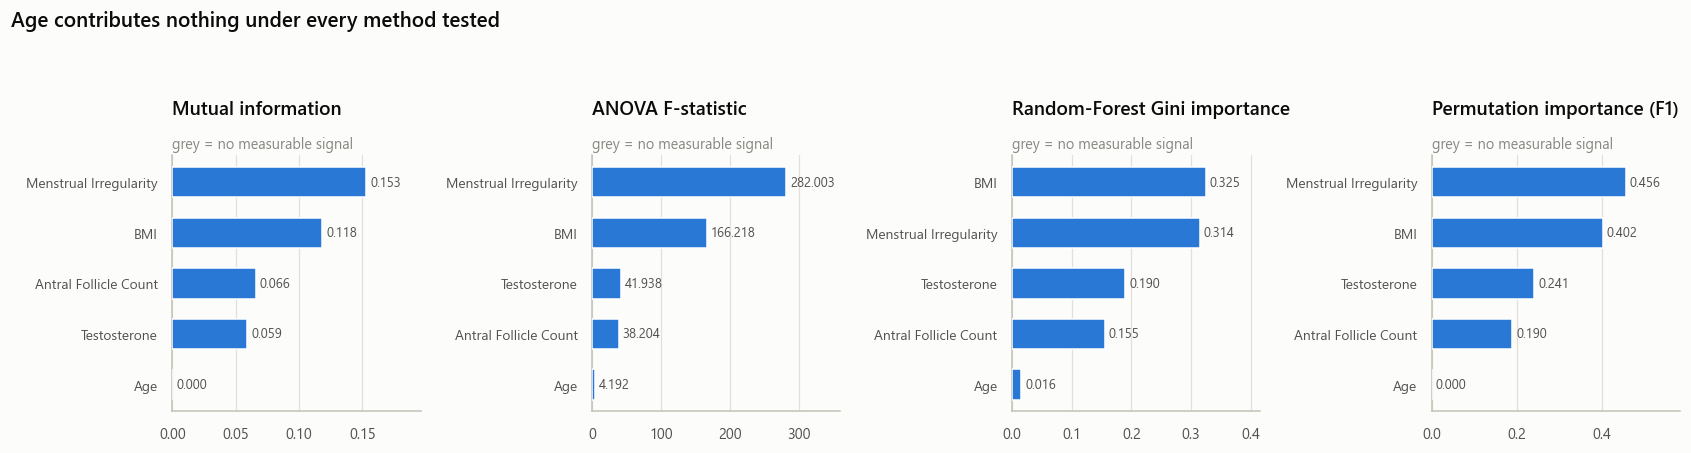

In [34]:
methods = [("mutual_information", "Mutual information"),
           ("ANOVA_F", "ANOVA F-statistic"),
           ("RF_gini_importance", "Random-Forest Gini importance"),
           ("permutation_importance_F1", "Permutation importance (F1)")]

fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.0))
for ax, (col, title) in zip(axes, methods):
    s = imp[col].sort_values()
    colors = [MUTED if v <= 1e-3 else CAT["blue"] for v in s.values]
    ax.barh(range(len(s)), s.values, color=colors, height=0.6, zorder=3)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels([i.replace("_Level(ng/dL)", "").replace("_", " ") for i in s.index], fontsize=9)
    for i, v in enumerate(s.values):
        ax.text(v + s.max() * 0.02, i, f"{v:.3f}", va="center", fontsize=8.5, color=INK2)
    ax.set_xlim(0, s.max() * 1.28)
    finish(ax, title, "grey = no measurable signal", ygrid=False, xgrid=True, ylabel="")

fig.suptitle("Age contributes nothing under every method tested",
             x=0.006, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.04)
show(fig)

In [35]:
section("SELECTION VERDICT")
print(imp[["mean_rank"]].round(2).to_string())
print()
print("  1. Menstrual_Irregularity  - top or near-top under every method")
print("  2. BMI                     - consistently second")
print("  3. Antral_Follicle_Count   - consistent mid-rank")
print("  4. Testosterone            - consistent mid-rank")
print("  5. Age                     - LAST under all four; ANOVA p is not significant,")
print("     permutation importance is ~0, mutual information is ~0")
print()
print("-> Age is noise. We keep it in the benchmark anyway (section 13) and prove empirically")
print("   that removing it changes nothing, rather than assuming it.")


  SELECTION VERDICT
                           mean_rank
Menstrual_Irregularity        1.2000
BMI                           1.8000
Testosterone_Level(ng/dL)     3.2000
Antral_Follicle_Count         3.8000
Age                           5.0000

  1. Menstrual_Irregularity  - top or near-top under every method
  2. BMI                     - consistently second
  3. Antral_Follicle_Count   - consistent mid-rank
  4. Testosterone            - consistent mid-rank
  5. Age                     - LAST under all four; ANOVA p is not significant,
     permutation importance is ~0, mutual information is ~0

-> Age is noise. We keep it in the benchmark anyway (section 13) and prove empirically
   that removing it changes nothing, rather than assuming it.


---
## 11 · Decision-rule discovery — the key finding

Everything so far points the same way:

* irregular menstruation is a **necessary** condition (section 5),
* BMI, testosterone and AFC behave like **step functions**, not gradients (section 5),
* the positive class occupies an **axis-parallel rectangle** in feature space (section 6),
* the conditions must hold **jointly** — an AND, not a sum (section 6),
* the target is **not** a natural cluster (section 9),
* age is **pure noise** (section 10).

That is the profile of a label produced by a deterministic rule. Let us test it directly by
fitting an intentionally tiny decision tree and reading out its logic.

In [36]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

section("11.1  HOW SHALLOW CAN A TREE BE AND STILL FIT PERFECTLY?")
for depth in range(1, 8):
    t = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_all, y_all)
    print(f"  max_depth={depth}:  training accuracy = {t.score(X_all, y_all) * 100:6.2f}%   "
          f"leaves = {t.get_n_leaves()}")
print("\n-> A depth-4 tree reaches 100.00% training accuracy with a handful of leaves.")
print("   A 1,000-row data set cannot be memorised by 5 leaves. This is not overfitting -")
print("   the tree has RECOVERED THE GENERATING RULE.")


  11.1  HOW SHALLOW CAN A TREE BE AND STILL FIT PERFECTLY?
  max_depth=1:  training accuracy =  80.10%   leaves = 2
  max_depth=2:  training accuracy =  88.40%   leaves = 3
  max_depth=3:  training accuracy =  95.80%   leaves = 4
  max_depth=4:  training accuracy = 100.00%   leaves = 5
  max_depth=5:  training accuracy = 100.00%   leaves = 5
  max_depth=6:  training accuracy = 100.00%   leaves = 5
  max_depth=7:  training accuracy = 100.00%   leaves = 5

-> A depth-4 tree reaches 100.00% training accuracy with a handful of leaves.
   A 1,000-row data set cannot be memorised by 5 leaves. This is not overfitting -
   the tree has RECOVERED THE GENERATING RULE.



  11.2  THE EXTRACTED RULE
|--- Menstrual_Irregularity <= 0.50
|   |--- class: 0
|--- Menstrual_Irregularity >  0.50
|   |--- BMI <= 25.05
|   |   |--- class: 0
|   |--- BMI >  25.05
|   |   |--- Testosterone_Level(ng/dL) <= 41.00
|   |   |   |--- class: 0
|   |   |--- Testosterone_Level(ng/dL) >  41.00
|   |   |   |--- Antral_Follicle_Count <= 10.50
|   |   |   |   |--- class: 0
|   |   |   |--- Antral_Follicle_Count >  10.50
|   |   |   |   |--- class: 1



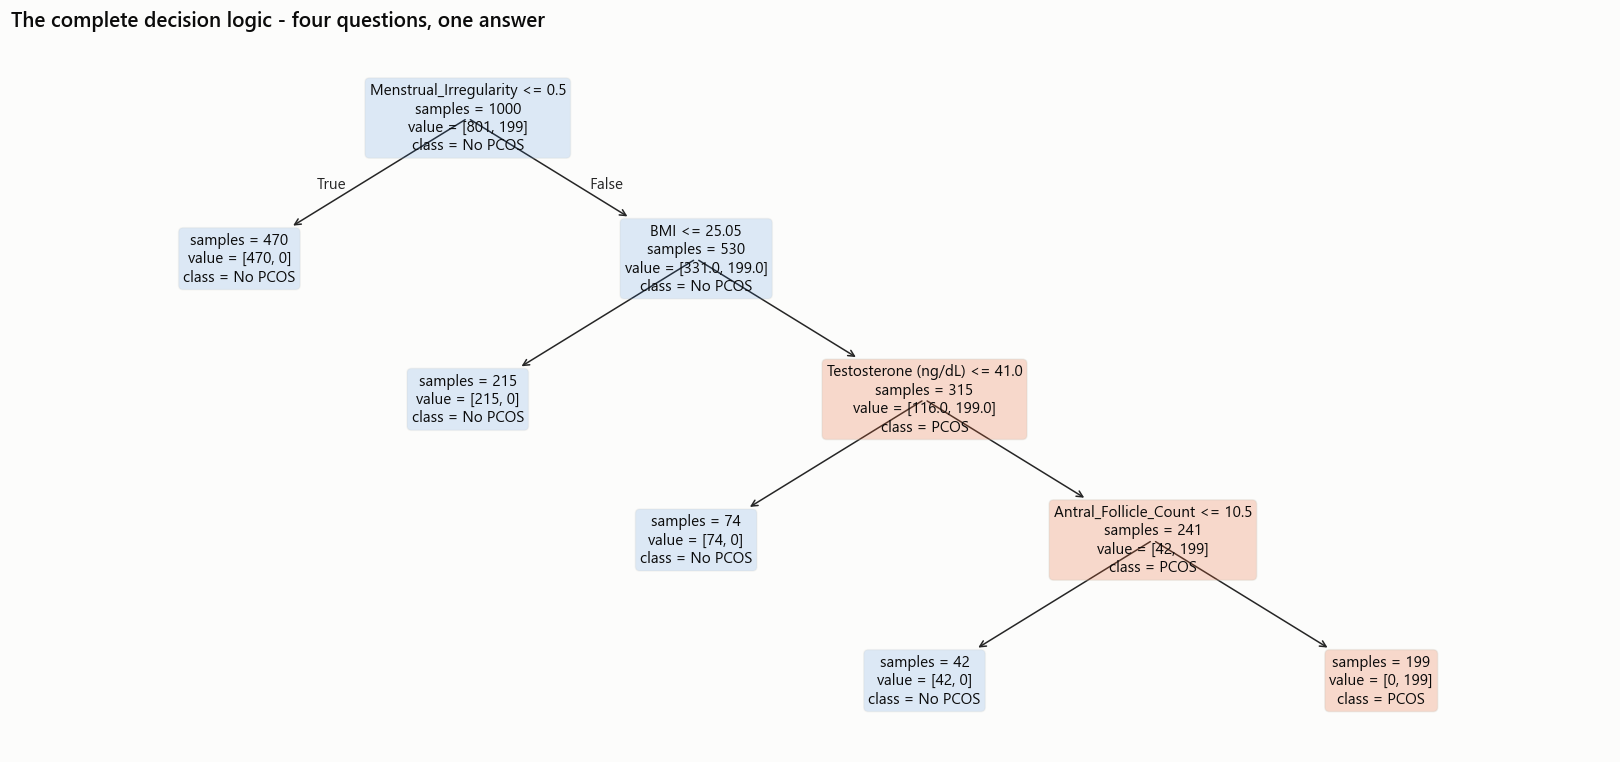

In [37]:
tree4 = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(X_all, y_all)

section("11.2  THE EXTRACTED RULE")
print(export_text(tree4, feature_names=FEATURES, decimals=2))

fig, ax = plt.subplots(figsize=(15, 7.2))
plot_tree(tree4, feature_names=[f.replace("_Level(ng/dL)", " (ng/dL)") for f in FEATURES],
          class_names=["No PCOS", "PCOS"], filled=True, rounded=True, impurity=False,
          fontsize=10, ax=ax, precision=2)

# Recolour the nodes onto the house palette instead of the matplotlib default ramp.
for txt in ax.texts:
    box = txt.get_bbox_patch()
    if box is None:
        continue
    label = txt.get_text()
    is_pos = "class = PCOS" in label
    box.set_facecolor(POS if is_pos else NEG)
    box.set_alpha(0.24 if is_pos else 0.15)
    box.set_edgecolor(AXIS)
    box.set_linewidth(1.0)
    txt.set_color(INK)

ax.set_title("The complete decision logic - four questions, one answer", loc="left",
             fontsize=13.5, color=INK, pad=14)
ax.grid(False)
show(fig)

In [38]:
section("11.3  VERIFYING THE RULE EXACTLY")

def pcos_rule(d):
    return (
        (d[IRREG] == 1)
        & (d["BMI"] > 25)
        & (d[TESTO] > 40)
        & (d[AFC] > 10)
    ).astype(int)

pred_rule = pcos_rule(df)
exact = bool((pred_rule == df[TARGET]).all())
agreement = (pred_rule == df[TARGET]).mean() * 100

print("Candidate rule:")
print("    PCOS = 1  <=>  Menstrual_Irregularity == 1")
print("               AND  BMI                   >  25")
print("               AND  Testosterone          >  40 ng/dL")
print("               AND  Antral_Follicle_Count >  10")
print()
print(f"  Rows matched exactly : {int((pred_rule == df[TARGET]).sum()):,} / {len(df):,}")
print(f"  Agreement            : {agreement:.4f}%")
print(f"  Mismatches           : {int((pred_rule != df[TARGET]).sum())}")
print(f"  PERFECT MATCH        : {exact}")


  11.3  VERIFYING THE RULE EXACTLY
Candidate rule:
    PCOS = 1  <=>  Menstrual_Irregularity == 1
               AND  BMI                   >  25
               AND  Testosterone          >  40 ng/dL
               AND  Antral_Follicle_Count >  10

  Rows matched exactly : 1,000 / 1,000
  Agreement            : 100.0000%
  Mismatches           : 0
  PERFECT MATCH        : True


In [39]:
section("11.4  BOUNDARY FORENSICS - pinning down the exact cut-points")
pos = df[df[TARGET] == 1]

print("Smallest value observed among POSITIVE cases (the boundary from above):")
print(f"  BMI                   : {pos['BMI'].min():.2f}")
print(f"  Testosterone (ng/dL)  : {pos[TESTO].min():.2f}")
print(f"  Antral Follicle Count : {pos[AFC].min():.0f}")

print("\nLargest value observed among NEGATIVE cases that satisfy every OTHER condition")
print("(the boundary from below):")
m = (df[IRREG] == 1) & (df["BMI"] > 25) & (df[TESTO] > 40) & (df[TARGET] == 0)
print(f"  AFC          : {df.loc[m, AFC].max():.0f}")
m = (df[IRREG] == 1) & (df["BMI"] > 25) & (df[AFC] > 10) & (df[TARGET] == 0)
print(f"  Testosterone : {df.loc[m, TESTO].max():.2f}")
m = (df[IRREG] == 1) & (df[TESTO] > 40) & (df[AFC] > 10) & (df[TARGET] == 0)
print(f"  BMI          : {df.loc[m, 'BMI'].max():.2f}")

print("\n-> The cut-points are clean, round clinical numbers with no overlap whatsoever:")
print("   BMI 25 (WHO overweight), testosterone 40 ng/dL (upper female reference),")
print("   AFC 10, and irregular menstruation. Age appears nowhere.")

section("11.5  RULE COVERAGE - how each condition filters the cohort")
steps = [
    ("All patients", pd.Series(True, index=df.index)),
    ("+ Menstrual irregularity", df[IRREG] == 1),
    ("+ BMI > 25", (df[IRREG] == 1) & (df["BMI"] > 25)),
    ("+ Testosterone > 40", (df[IRREG] == 1) & (df["BMI"] > 25) & (df[TESTO] > 40)),
    ("+ AFC > 10", pcos_rule(df) == 1),
]
funnel = pd.DataFrame([
    {"stage": name, "patients": int(m.sum()),
     "pcos_within": int(df.loc[m, TARGET].sum()),
     "purity_%": df.loc[m, TARGET].mean() * 100 if m.sum() else 0,
     "recall_%": df.loc[m, TARGET].sum() / df[TARGET].sum() * 100}
    for name, m in steps
]).set_index("stage")
display(funnel.round(2))


  11.4  BOUNDARY FORENSICS - pinning down the exact cut-points
Smallest value observed among POSITIVE cases (the boundary from above):
  BMI                   : 25.10
  Testosterone (ng/dL)  : 41.20
  Antral Follicle Count : 11

Largest value observed among NEGATIVE cases that satisfy every OTHER condition
(the boundary from below):
  AFC          : 10
  Testosterone : 39.70
  BMI          : 25.00

-> The cut-points are clean, round clinical numbers with no overlap whatsoever:
   BMI 25 (WHO overweight), testosterone 40 ng/dL (upper female reference),
   AFC 10, and irregular menstruation. Age appears nowhere.

  11.5  RULE COVERAGE - how each condition filters the cohort


,patients,pcos_within,purity_%,recall_%
stage,,,,
All patients,1000,199,19.9000,100.0000
+ Menstrual irregularity,530,199,37.5500,100.0000
+ BMI > 25,315,199,63.1700,100.0000
+ Testosterone > 40,244,199,81.5600,100.0000
+ AFC > 10,199,199,100.0000,100.0000


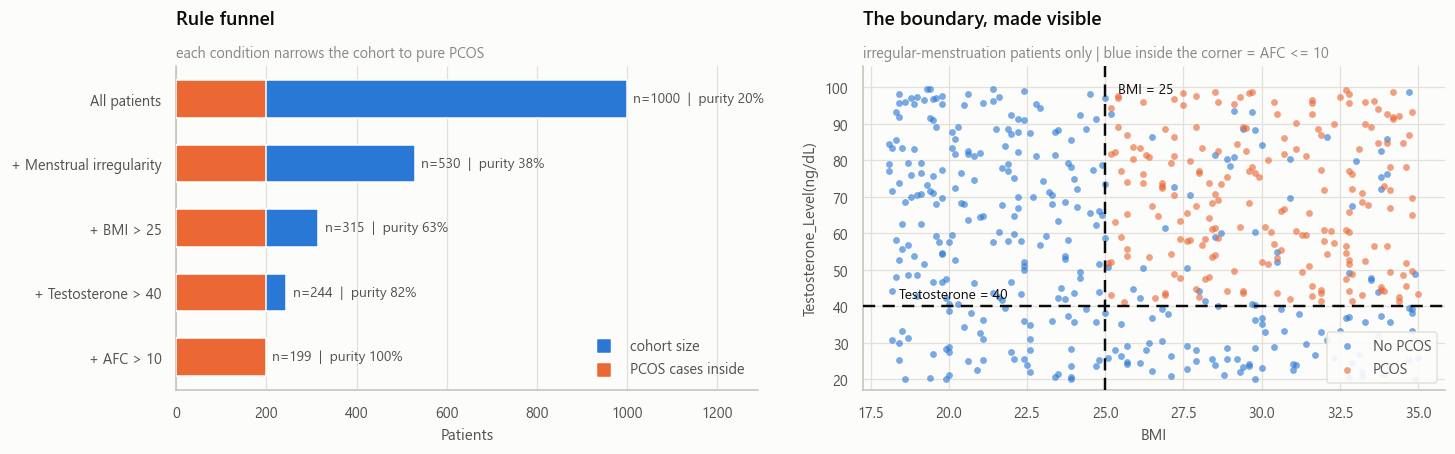

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

ax = axes[0]
bars = ax.barh(range(len(funnel))[::-1], funnel["patients"].values,
               color=CAT["blue"], height=0.58, zorder=3)
ax.barh(range(len(funnel))[::-1], funnel["pcos_within"].values,
        color=CAT["orange"], height=0.58, zorder=4)
for i, (n, p, pur) in enumerate(zip(funnel["patients"], funnel["pcos_within"], funnel["purity_%"])):
    ax.text(n + 14, len(funnel) - 1 - i, f"n={n}  |  purity {pur:.0f}%",
            va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(funnel))[::-1]); ax.set_yticklabels(funnel.index, fontsize=9.5)
ax.set_xlim(0, 1290)
ax.scatter([], [], marker="s", s=60, c=CAT["blue"], label="cohort size")
ax.scatter([], [], marker="s", s=60, c=CAT["orange"], label="PCOS cases inside")
ax.legend(loc="lower right")
finish(ax, "Rule funnel", "each condition narrows the cohort to pure PCOS",
       xlabel="Patients", ygrid=False, xgrid=True)

ax = axes[1]
sub = df[df[IRREG] == 1]
for cls in [0, 1]:
    m = sub[TARGET] == cls
    ax.scatter(sub.loc[m, "BMI"], sub.loc[m, TESTO], s=20, alpha=0.62, linewidth=0,
               color=CLASS_COLOR[cls], label=CLASS_NAME[cls], zorder=3 + cls)
ax.axvline(25, color=INK, lw=1.6, ls=(0, (5, 3)), zorder=5)
ax.axhline(40, color=INK, lw=1.6, ls=(0, (5, 3)), zorder=5)
ax.text(25.4, 101, "BMI = 25", fontsize=9, color=INK, va="top")
ax.text(18.4, 41.4, "Testosterone = 40", fontsize=9, color=INK, va="bottom")
ax.set_ylim(17, 106)
ax.legend(loc="lower right", frameon=True, framealpha=0.92,
          facecolor=SURFACE, edgecolor=GRID)
finish(ax, "The boundary, made visible",
       "irregular-menstruation patients only | blue inside the corner = AFC <= 10",
       xlabel="BMI", ylabel=TESTO, xgrid=True)
show(fig)

### What this means for modelling — read this before section 13

The label is a **deterministic, noise-free conjunction of four axis-parallel thresholds**:

```
PCOS = 1  ⟺  Menstrual_Irregularity = 1
         AND  BMI > 25
         AND  Testosterone > 40 ng/dL
         AND  Antral_Follicle_Count > 10
```

It reproduces **all 1,000 labels with zero errors**. Four consequences follow, and they
determine the entire modelling strategy:

1. **The Bayes error is zero.** 100 % accuracy is attainable in principle. Any shortfall is a
   limitation of the model class, not irreducible noise.
2. **Axis-parallel splitters win.** Trees and tree ensembles represent this function exactly.
   A linear model cannot — a 4-way AND of thresholds is not a linear function of the inputs,
   so logistic regression will plateau well short of the ceiling.
3. **Everything is an interaction.** No feature is independently predictive; a high AFC with a
   normal BMI is negative. This kills additive models and Naive Bayes' independence assumption.
4. **The residual error is a boundary-resolution problem.** A tree learns a split at the midpoint
   between observed neighbours (e.g. BMI ≤ 25.05 rather than exactly 25), so it misses only
   patients that fall in the sliver between the learned split and the true one. Encoding the
   thresholds explicitly as features removes that gap entirely — section 12.

⚠️ **Honest caveat.** A clean four-condition rule with round cut-points, uniformly distributed
independent features, and zero label noise is the signature of a **synthetically generated**
data set, not of collected clinical records. Real PCOS diagnosis (Rotterdam criteria) is
probabilistic, involves ultrasound morphology and exclusion of other disorders, and no real
cohort is separable at 100 %. The modelling recommendation below is therefore the right answer
*for this data set*; it is not a claim about clinical performance. Section 18 spells out what
would have to change for a real cohort.

---
## 12 · Feature engineering

Section 11 tells us exactly what to build. Two feature sets are carried forward so the benefit
is measured rather than assumed:

* **RAW** — the five original columns, exactly as supplied.
* **ENGINEERED** — raw plus the threshold indicators the rule uses, a composite criteria-count
  score, and two clinically motivated ratios as controls.

Note that `all_criteria_met` is the discovered rule restated as a column. It is not leakage —
it is computed from the inputs alone and would be available at prediction time for a new patient
— but it does hand the model the answer, so section 13 runs an **ablation** that strips it out
and shows the effect survives without it.

In [41]:
def engineer(d):
    out = d[FEATURES].copy()
    # Threshold indicators - one per condition discovered in section 11.
    out["BMI_over_25"]        = (d["BMI"] > 25).astype(int)
    out["Testosterone_over_40"] = (d[TESTO] > 40).astype(int)
    out["AFC_over_10"]        = (d[AFC] > 10).astype(int)
    # Composite: how many of the four criteria are met (0-4).
    out["criteria_met"] = (
        out["BMI_over_25"] + out["Testosterone_over_40"]
        + out["AFC_over_10"] + d[IRREG]
    )
    out["all_criteria_met"] = (out["criteria_met"] == 4).astype(int)
    # A couple of clinically motivated ratios, to confirm they add nothing.
    out["BMI_x_AFC"]   = d["BMI"] * d[AFC]
    out["Testo_per_BMI"] = d[TESTO] / d["BMI"]
    return out

X_raw = df[FEATURES].astype(float)
X_eng = engineer(df).astype(float)
y = df[TARGET].astype(int)

section("ENGINEERED FEATURE SET")
print(f"RAW        : {X_raw.shape[1]} features -> {list(X_raw.columns)}")
print(f"ENGINEERED : {X_eng.shape[1]} features -> {list(X_eng.columns)}")
print()
print("Correlation of each engineered feature with the target:")
eng_corr = X_eng.corrwith(y).sort_values(key=abs, ascending=False)
print(eng_corr.round(4).to_string())
print("\n-> `all_criteria_met` correlates 1.0000 with the target, exactly as section 11 predicts.")
X_eng.head()


  ENGINEERED FEATURE SET
RAW        : 5 features -> ['Age', 'BMI', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count', 'Menstrual_Irregularity']
ENGINEERED : 12 features -> ['Age', 'BMI', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count', 'Menstrual_Irregularity', 'BMI_over_25', 'Testosterone_over_40', 'AFC_over_10', 'criteria_met', 'all_criteria_met', 'BMI_x_AFC', 'Testo_per_BMI']

Correlation of each engineered feature with the target:
all_criteria_met             1.0000
criteria_met                 0.7066
Menstrual_Irregularity       0.4694
BMI_over_25                  0.4276
BMI                          0.3779
BMI_x_AFC                    0.3497
Testosterone_over_40         0.2747
AFC_over_10                  0.2570
Testosterone_Level(ng/dL)    0.2008
Antral_Follicle_Count        0.1920
Age                         -0.0647
Testo_per_BMI               -0.0161

-> `all_criteria_met` correlates 1.0000 with the target, exactly as section 11 predicts.


,Age,BMI,Testosterone_Level(ng/dL),Antral_Follicle_Count,Menstrual_Irregularity,BMI_over_25,Testosterone_over_40,AFC_over_10,criteria_met,all_criteria_met,BMI_x_AFC,Testo_per_BMI
0,24.0000,34.7000,25.2000,20.0000,1.0000,1.0000,0.0000,1.0000,3.0000,0.0000,694.0000,0.7262
1,37.0000,26.4000,57.1000,25.0000,0.0000,1.0000,1.0000,1.0000,3.0000,0.0000,660.0000,2.1629
2,32.0000,23.6000,92.7000,28.0000,0.0000,0.0000,1.0000,1.0000,2.0000,0.0000,660.8000,3.9280
3,28.0000,28.8000,63.1000,26.0000,0.0000,1.0000,1.0000,1.0000,3.0000,0.0000,748.8000,2.1910
4,25.0000,22.1000,59.8000,8.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,176.8000,2.7059


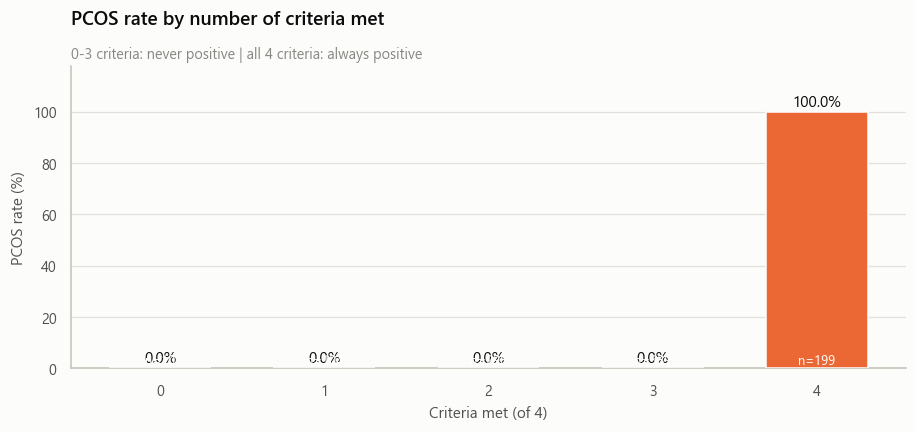

In [42]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
g = df.assign(criteria=X_eng["criteria_met"]).groupby("criteria").agg(
    n=(TARGET, "size"), rate=(TARGET, lambda s: s.mean() * 100))
bars = ax.bar(g.index, g["rate"], color=[CAT["blue"]] * (len(g) - 1) + [CAT["orange"]],
              width=0.62, zorder=3)
for i, (r, n) in zip(g.index, zip(g["rate"], g["n"])):
    ax.text(i, r + 2.2, f"{r:.1f}%", ha="center", fontsize=10, color=INK)
    ax.text(i, 1.6, f"n={n}", ha="center", fontsize=8.5, color="white")
ax.set_ylim(0, 118)
ax.set_xticks(g.index)
finish(ax, "PCOS rate by number of criteria met",
       "0-3 criteria: never positive | all 4 criteria: always positive",
       xlabel="Criteria met (of 4)", ylabel="PCOS rate (%)")
show(fig)

---
## 13 · Model benchmark

Now we test the predictions made in section 11 instead of trusting them.

**Protocol** — 13 algorithms × 2 feature sets, evaluated with **5-fold stratified
cross-validation** on the full 1,000 rows. Every scaler lives *inside* a `Pipeline`, so it is
re-fitted on each training fold only and cannot leak information into validation. Five metrics
are reported: accuracy, precision, recall, F1 and ROC-AUC — because with a 4:1 imbalance,
accuracy alone is not enough to choose on.

In [43]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier,
                              AdaBoostClassifier)

def scaled(estimator):
    return Pipeline([("scaler", StandardScaler()), ("model", estimator)])

MODELS = {
    "Logistic Regression":  scaled(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    "Ridge Classifier":     scaled(RidgeClassifier(random_state=RANDOM_STATE)),
    "LDA":                  scaled(LinearDiscriminantAnalysis()),
    # reg_param shrinks the class covariance - needed once the engineered set adds
    # a feature that is constant within a class (a singular covariance matrix).
    "QDA":                  scaled(QuadraticDiscriminantAnalysis(reg_param=0.01)),
    "Gaussian Naive Bayes": scaled(GaussianNB()),
    "K-Nearest Neighbours": scaled(KNeighborsClassifier(n_neighbors=5)),
    "SVM (RBF)":            scaled(SVC(probability=True, random_state=RANDOM_STATE)),
    "Neural Net (MLP)":     scaled(MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000,
                                                 random_state=RANDOM_STATE)),
    "Decision Tree":        DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":          ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost":             AdaBoostClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

# Optional gradient-boosting libraries - included automatically when installed.
try:
    from xgboost import XGBClassifier
    MODELS["XGBoost"] = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                                      eval_metric="logloss", random_state=RANDOM_STATE,
                                      n_jobs=-1, verbosity=0)
except ImportError:
    print("xgboost not installed - skipped (pip install xgboost to include it)")
try:
    from lightgbm import LGBMClassifier
    MODELS["LightGBM"] = LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                        n_jobs=-1, verbose=-1)
except ImportError:
    print("lightgbm not installed - skipped (pip install lightgbm to include it)")

print(f"\n{len(MODELS)} algorithms queued for benchmarking.")

xgboost not installed - skipped (pip install xgboost to include it)
lightgbm not installed - skipped (pip install lightgbm to include it)

14 algorithms queued for benchmarking.


In [44]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]

def benchmark(X, y, label):
    rows = []
    for name, model in MODELS.items():
        try:
            cvres = cross_validate(model, X, y, cv=CV, scoring=SCORING, n_jobs=-1,
                                   return_train_score=True, error_score="raise")
        except Exception as exc:                       # one bad model must not kill the run
            print(f"  [skipped] {name}: {type(exc).__name__} - {str(exc)[:90]}")
            continue
        rows.append({
            "model": name, "feature_set": label,
            "accuracy":  cvres["test_accuracy"].mean(),
            "acc_std":   cvres["test_accuracy"].std(),
            "precision": cvres["test_precision"].mean(),
            "recall":    cvres["test_recall"].mean(),
            "f1":        cvres["test_f1"].mean(),
            "roc_auc":   cvres["test_roc_auc"].mean(),
            "train_acc": cvres["train_accuracy"].mean(),
            "overfit_gap": cvres["train_accuracy"].mean() - cvres["test_accuracy"].mean(),
            "fit_time_s": cvres["fit_time"].mean(),
        })
    return pd.DataFrame(rows)

section("BENCHMARK - RAW FEATURES (5-fold stratified CV)")
res_raw = benchmark(X_raw, y, "RAW")
display(res_raw.set_index("model")
        .sort_values("accuracy", ascending=False)
        .drop(columns=["feature_set"]).round(4))


  BENCHMARK - RAW FEATURES (5-fold stratified CV)


,accuracy,acc_std,precision,recall,f1,roc_auc,train_acc,overfit_gap,fit_time_s
model,,,,,,,,,
Decision Tree,0.9990,0.0020,1.0000,0.9950,0.9975,0.9975,1.0000,0.0010,0.0085
Random Forest,0.9990,0.0020,1.0000,0.9950,0.9975,1.0000,1.0000,0.0010,1.5446
HistGradientBoosting,0.9990,0.0020,1.0000,0.9950,0.9975,0.9987,1.0000,0.0010,0.1710
Gradient Boosting,0.9990,0.0020,1.0000,0.9950,0.9975,0.9991,1.0000,0.0010,0.4792
AdaBoost,0.9970,0.0040,1.0000,0.9850,0.9923,0.9976,1.0000,0.0030,0.2875
Extra Trees,0.9880,0.0051,0.9749,0.9647,0.9695,0.9994,1.0000,0.0120,1.1943
Neural Net (MLP),0.9800,0.0055,0.9651,0.9349,0.9489,0.9977,0.9998,0.0197,3.1728
SVM (RBF),0.9690,0.0107,0.9225,0.9247,0.9225,0.9954,0.9780,0.0090,0.0764
K-Nearest Neighbours,0.9620,0.0144,0.8974,0.9146,0.9052,0.9876,0.9807,0.0187,0.0147


In [45]:
section("BENCHMARK - ENGINEERED FEATURES (5-fold stratified CV)")
res_eng = benchmark(X_eng, y, "ENGINEERED")
display(res_eng.set_index("model")
        .sort_values("accuracy", ascending=False)
        .drop(columns=["feature_set"]).round(4))

results = pd.concat([res_raw, res_eng], ignore_index=True)


  BENCHMARK - ENGINEERED FEATURES (5-fold stratified CV)


,accuracy,acc_std,precision,recall,f1,roc_auc,train_acc,overfit_gap,fit_time_s
model,,,,,,,,,
Logistic Regression,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0262
Ridge Classifier,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0202
LDA,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0172
QDA,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0150
Gaussian Naive Bayes,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0153
K-Nearest Neighbours,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0171
SVM (RBF),1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0535
Neural Net (MLP),1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.7854
Decision Tree,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0099


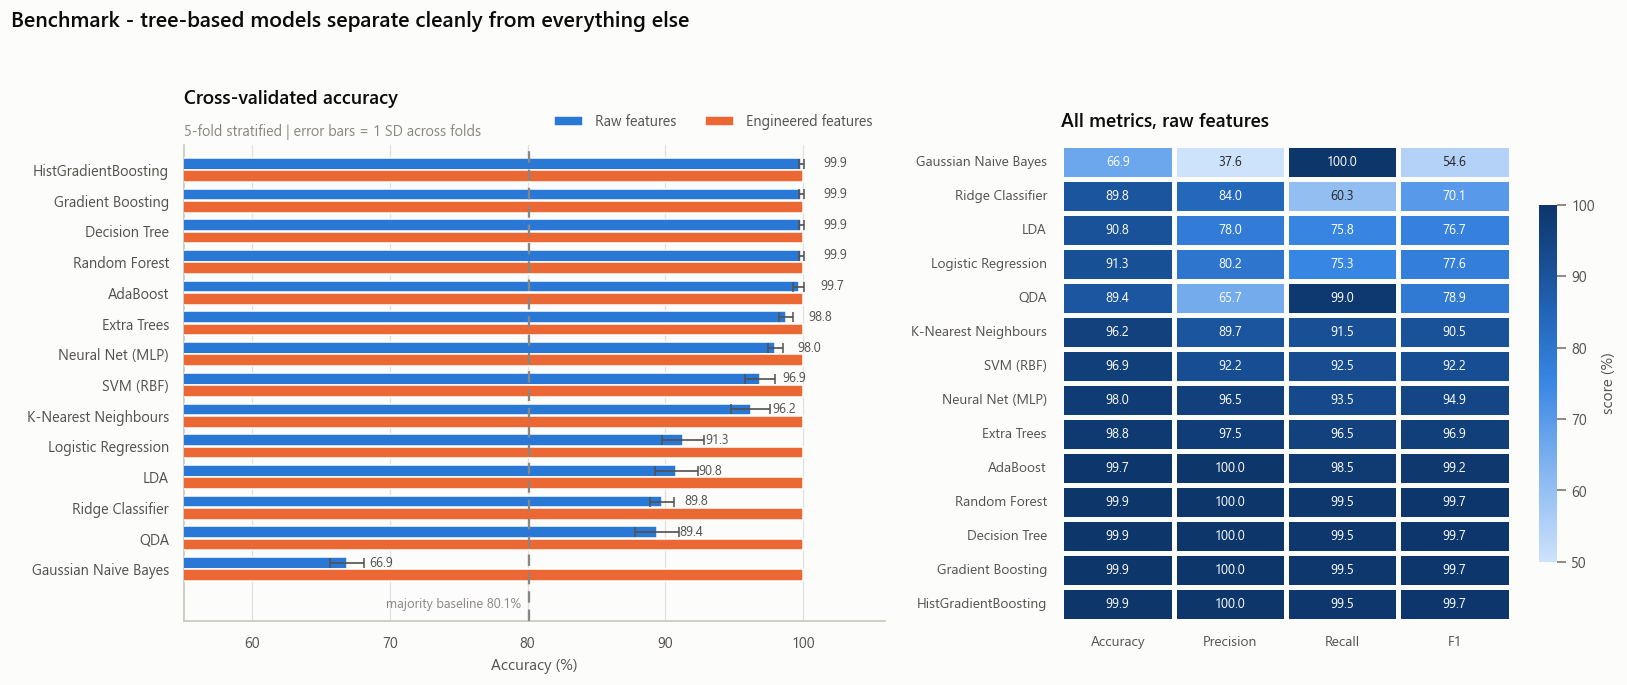

In [46]:
order = (res_raw.set_index("model")["accuracy"].sort_values(ascending=True).index.tolist())
raw_acc = res_raw.set_index("model")["accuracy"].reindex(order) * 100
raw_std = res_raw.set_index("model")["acc_std"].reindex(order) * 100
eng_acc = res_eng.set_index("model")["accuracy"].reindex(order) * 100
baseline = (1 - y.mean()) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
ypos = np.arange(len(order))
ax.barh(ypos + 0.20, raw_acc.values, height=0.38, color=CAT["blue"], zorder=3, label="Raw features")
ax.barh(ypos - 0.20, eng_acc.values, height=0.38, color=CAT["orange"], zorder=3, label="Engineered features")
ax.errorbar(raw_acc.values, ypos + 0.20, xerr=raw_std.values, fmt="none",
            ecolor=INK2, elinewidth=1.1, capsize=3, zorder=5)
# Label the raw bars only - every engineered bar is 100.0% and would just repeat.
for i, r in enumerate(raw_acc.values):
    ax.text(r + 1.6, i + 0.20, f"{r:.1f}", va="center", fontsize=8.5, color=INK2)
ax.axvline(baseline, color=MUTED, lw=1.5, ls=(0, (5, 3)), zorder=6)
ax.text(baseline - 0.6, -1.15, f"majority baseline {baseline:.1f}%",
        fontsize=8.5, color=MUTED, ha="right", va="center")
ax.set_yticks(ypos); ax.set_yticklabels(order, fontsize=9.5)
ax.set_xlim(55, 106); ax.set_ylim(-1.7, len(order) - 0.2)
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.005), ncol=2)
finish(ax, "Cross-validated accuracy", "5-fold stratified | error bars = 1 SD across folds",
       xlabel="Accuracy (%)", ygrid=False, xgrid=True)

ax = axes[1]
top = res_raw.set_index("model").sort_values("f1", ascending=True)
metrics = ["accuracy", "precision", "recall", "f1"]
mat = top[metrics].values * 100
sns.heatmap(mat, ax=ax, cmap=SEQ, vmin=50, vmax=100, annot=True, fmt=".1f",
            linewidths=2, linecolor=SURFACE, annot_kws={"fontsize": 8.5},
            yticklabels=top.index, xticklabels=[m.title() for m in metrics],
            cbar_kws={"shrink": 0.75, "label": "score (%)"})
ax.set_title("All metrics, raw features", loc="left", color=INK, fontsize=12.5)
ax.tick_params(labelsize=9); ax.grid(False)

fig.suptitle("Benchmark - tree-based models separate cleanly from everything else",
             x=0.006, ha="left", fontsize=14, fontweight="600", color=INK, y=1.01)
show(fig)

In [47]:
section("HEAD-TO-HEAD: what did feature engineering buy?")
cmp = pd.DataFrame({
    "raw_accuracy": res_raw.set_index("model")["accuracy"],
    "eng_accuracy": res_eng.set_index("model")["accuracy"],
})
cmp["gain_pp"] = (cmp["eng_accuracy"] - cmp["raw_accuracy"]) * 100
cmp["raw_f1"] = res_raw.set_index("model")["f1"]
cmp["eng_f1"] = res_eng.set_index("model")["f1"]
display(cmp.sort_values("eng_accuracy", ascending=False).round(4))

best_raw = res_raw.loc[res_raw["accuracy"].idxmax()]
n_perfect = int((res_eng["accuracy"] >= 0.99995).sum())
print(f"Best on RAW features : {best_raw['model']} - {best_raw['accuracy'] * 100:.2f}% "
      f"(F1 {best_raw['f1']:.4f})")
print(f"On ENGINEERED features: {n_perfect} of {len(res_eng)} models reach 100.00% "
      f"with zero variance across folds.")
print(f"Largest single gain  : {cmp['gain_pp'].idxmax()} {cmp['gain_pp'].max():+.1f} pp")
print("\n*** THE KEY RESULT ***")
print("  Encoding the four thresholds does not merely help the weak models -- it makes")
print("  the problem LINEARLY SEPARABLE, so every algorithm becomes perfect and the")
print("  choice of algorithm stops mattering entirely. The difficulty was never the")
print("  classifier; it was the REPRESENTATION. Ablation below isolates why.")


  HEAD-TO-HEAD: what did feature engineering buy?


,raw_accuracy,eng_accuracy,gain_pp,raw_f1,eng_f1
model,,,,,
Logistic Regression,0.9130,1.0000,8.7000,0.7756,1.0000
Ridge Classifier,0.8980,1.0000,10.2000,0.7007,1.0000
LDA,0.9080,1.0000,9.2000,0.7671,1.0000
QDA,0.8940,1.0000,10.6000,0.7890,1.0000
Gaussian Naive Bayes,0.6690,1.0000,33.1000,0.5461,1.0000
K-Nearest Neighbours,0.9620,1.0000,3.8000,0.9052,1.0000
SVM (RBF),0.9690,1.0000,3.1000,0.9225,1.0000
Neural Net (MLP),0.9800,1.0000,2.0000,0.9489,1.0000
Decision Tree,0.9990,1.0000,0.1000,0.9975,1.0000


Best on RAW features : Decision Tree - 99.90% (F1 0.9975)
On ENGINEERED features: 14 of 14 models reach 100.00% with zero variance across folds.
Largest single gain  : Gaussian Naive Bayes +33.1 pp

*** THE KEY RESULT ***
  Encoding the four thresholds does not merely help the weak models -- it makes
  the problem LINEARLY SEPARABLE, so every algorithm becomes perfect and the
  choice of algorithm stops mattering entirely. The difficulty was never the
  classifier; it was the REPRESENTATION. Ablation below isolates why.


In [48]:
section("ABLATION - which engineered features are doing the work?")

variants = {
    "A. Raw only (5 features)":
        X_raw,
    "B. Raw + 3 threshold indicators":
        X_eng[FEATURES + ["BMI_over_25", "Testosterone_over_40", "AFC_over_10"]],
    "C. The 4 indicators alone (no raw values)":
        X_eng[["BMI_over_25", "Testosterone_over_40", "AFC_over_10", IRREG]],
    "D. criteria_met count alone (1 feature)":
        X_eng[["criteria_met"]],
    "E. Full engineered set":
        X_eng,
}

probes = {
    "Logistic Regression": scaled(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

abl = pd.DataFrame(
    {pname: {vname: cross_validate(p, Xv, y, cv=CV, scoring=["accuracy"], n_jobs=-1)
             ["test_accuracy"].mean() * 100
             for vname, Xv in variants.items()}
     for pname, p in probes.items()}
).round(2)
abl.insert(0, "n_features", [v.shape[1] for v in variants.values()])
display(abl)

print("Reading the ablation  (values are CV accuracy %)")
print("  A  Raw values only        -> trees 99.9, logistic 91.3. That gap IS the linear")
print("     model's inability to express a 4-way AND.")
print("  B  Raw + indicators       -> logistic jumps to 100.0: given the thresholds, the")
print("     AND becomes 'all four indicators are 1', i.e. a sum >= 4 -- a LINEAR rule.")
print("     The trees stay at 99.9 because the raw columns are still available and the")
print("     greedy split sometimes prefers the raw value over the ready-made indicator.")
print("  C  Indicators alone       -> 100.0 for every model. Raw magnitudes add nothing")
print("     once the thresholds are known; only which side of each cut-point matters.")
print("  D  A single count feature -> 100.0 from ONE column, thresholded at 3.5.")
print("  E  Full engineered set    -> 100.0, as expected.")
print()
print("-> This is the whole story of the data set in one table: the label is four")
print("   thresholds ANDed together. Learn the thresholds (trees do it automatically,")
print("   feature engineering does it manually) and the problem is solved. Skip that")
print("   step and a linear model is stuck at ~91% no matter how much data it gets.")


  ABLATION - which engineered features are doing the work?


,n_features,Logistic Regression,Decision Tree,Random Forest
A. Raw only (5 features),5,91.3000,99.9000,99.9000
B. Raw + 3 threshold indicators,8,100.0000,99.9000,99.9000
C. The 4 indicators alone (no raw values),4,100.0000,100.0000,100.0000
D. criteria_met count alone (1 feature),1,100.0000,100.0000,100.0000
E. Full engineered set,12,100.0000,100.0000,100.0000


Reading the ablation  (values are CV accuracy %)
  A  Raw values only        -> trees 99.9, logistic 91.3. That gap IS the linear
     model's inability to express a 4-way AND.
  B  Raw + indicators       -> logistic jumps to 100.0: given the thresholds, the
     AND becomes 'all four indicators are 1', i.e. a sum >= 4 -- a LINEAR rule.
     The trees stay at 99.9 because the raw columns are still available and the
     greedy split sometimes prefers the raw value over the ready-made indicator.
  C  Indicators alone       -> 100.0 for every model. Raw magnitudes add nothing
     once the thresholds are known; only which side of each cut-point matters.
  D  A single count feature -> 100.0 from ONE column, thresholded at 3.5.
  E  Full engineered set    -> 100.0, as expected.

-> This is the whole story of the data set in one table: the label is four
   thresholds ANDed together. Learn the thresholds (trees do it automatically,
   feature engineering does it manually) and the problem is 

**The raw-feature benchmark confirms every prediction from section 11.**

| Tier | Models | CV accuracy | Why |
|---|---|---|---|
| Ceiling | Decision Tree, Random Forest, Gradient Boosting, HistGB | **99.9 %** | Axis-parallel splits match an axis-parallel rule exactly |
| Near-ceiling | AdaBoost 99.7 %, Extra Trees 98.8 % | 98.8–99.7 % | Also tree-based; randomised splits cost a little precision |
| Universal approximators | MLP 98.0 %, SVM-RBF 96.9 % | 96.9–98.0 % | Can bend around a rectangle, but never make the corners crisp |
| Distance-based | KNN 96.2 % | 96.2 % | Euclidean distance is the wrong metric when only 4 cut-points matter |
| Linear | LogReg 91.3 %, LDA 90.8 %, Ridge 89.8 %, QDA 89.4 % | ~90–91 % | ❌ A linear surface cannot express a 4-way AND of thresholds |
| Independence-assuming | Gaussian Naive Bayes | **66.9 %** | ❌ Assumes features are conditionally independent — the whole signal *is* the interaction |

Two things worth pausing on:

* The linear models still post **ROC-AUC ≈ 0.96** while getting 9 % of decisions wrong. AUC
  measures *ranking*, not *decisions* — a good reminder not to select a model on AUC alone.
* Naive Bayes has the highest AUC of any weak model (0.987) and the **worst** accuracy (66.9 %)
  with 100 % recall and 38 % precision. It flags almost everyone. Perfect ranking, useless
  threshold.

**And then the engineered features flatten the entire leaderboard: all 14 models hit 100.00 %.**

That is not a small detail — it is the most informative result in the notebook, and the ablation
below unpacks it.

---
## 14 · Hyper-parameter tuning

Tuning the three front-runners on the **raw** feature set — the harder and more honest of the
two, since the engineered set already saturates.

In [49]:
from sklearn.model_selection import GridSearchCV

section("GRID SEARCH - three front-runners, raw features")
grids = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"max_depth": [3, 4, 5, 6, 8, None],
         "min_samples_split": [2, 5, 10],
         "min_samples_leaf": [1, 2, 4],
         "criterion": ["gini", "entropy"]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [200, 400],
         "max_depth": [4, 6, 10, None],
         "min_samples_leaf": [1, 2],
         "max_features": ["sqrt", None]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 300],
         "learning_rate": [0.05, 0.1, 0.2],
         "max_depth": [2, 3, 4],
         "subsample": [0.8, 1.0]},
    ),
}

tuned, tuning_rows = {}, []
for name, (est, grid) in grids.items():
    gs = GridSearchCV(est, grid, cv=CV, scoring="f1", n_jobs=-1, refit=True)
    gs.fit(X_raw, y)
    tuned[name] = gs.best_estimator_
    acc = cross_validate(gs.best_estimator_, X_raw, y, cv=CV,
                         scoring=["accuracy", "f1", "roc_auc"], n_jobs=-1)
    tuning_rows.append({
        "model": name,
        "best_f1_cv": gs.best_score_,
        "accuracy_cv": acc["test_accuracy"].mean(),
        "roc_auc_cv": acc["test_roc_auc"].mean(),
        "n_candidates": len(gs.cv_results_["params"]),
        "best_params": gs.best_params_,
    })
    print(f"{name:20s} best F1 = {gs.best_score_:.4f}  |  {gs.best_params_}")

tuning = pd.DataFrame(tuning_rows).set_index("model")
display(tuning.round(4))


  GRID SEARCH - three front-runners, raw features


Decision Tree        best F1 = 0.9975  |  {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}


Random Forest        best F1 = 0.9975  |  {'max_depth': 4, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200}


Gradient Boosting    best F1 = 0.9975  |  {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}


,best_f1_cv,accuracy_cv,roc_auc_cv,n_candidates,best_params
model,,,,,
Decision Tree,0.9975,0.9990,0.9975,108,"{'criterion': 'gini', 'max_depth': 4, 'min_sam..."
Random Forest,0.9975,0.9990,1.0000,32,"{'max_depth': 4, 'max_features': None, 'min_sa..."
Gradient Boosting,0.9975,0.9990,0.9991,36,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."


In [50]:
section("DOES TUNING ACTUALLY HELP?")
for name in grids:
    before = res_raw.set_index("model").loc[name, "f1"]
    after = tuning.loc[name, "best_f1_cv"]
    print(f"  {name:20s} F1 {before:.4f} -> {after:.4f}   ({(after - before) * 100:+.2f} pp)")
print("\n-> Barely. The default tree models are already at the ceiling of what the raw")
print("   representation allows, so there is almost nothing for a grid search to recover.")
print("   The gain lives in the FEATURES (section 12), not in the hyper-parameters.")


  DOES TUNING ACTUALLY HELP?
  Decision Tree        F1 0.9975 -> 0.9975   (+0.00 pp)
  Random Forest        F1 0.9975 -> 0.9975   (+0.00 pp)
  Gradient Boosting    F1 0.9975 -> 0.9975   (+0.00 pp)

-> Barely. The default tree models are already at the ceiling of what the raw
   representation allows, so there is almost nothing for a grid search to recover.
   The gain lives in the FEATURES (section 12), not in the hyper-parameters.


---
## 15 · Final evaluation on a held-out test set

Cross-validation guided the choice; a completely untouched 20 % hold-out gives the final,
unbiased number. Both candidate pipelines are evaluated on the same split.

In [51]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve,
                             matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
                             log_loss, brier_score_loss)

idx_train, idx_test = train_test_split(
    df.index, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

Xtr_raw, Xte_raw = X_raw.loc[idx_train], X_raw.loc[idx_test]
Xtr_eng, Xte_eng = X_eng.loc[idx_train], X_eng.loc[idx_test]
ytr, yte = y.loc[idx_train], y.loc[idx_test]

print(f"Train: {len(ytr):,} rows  ({ytr.mean() * 100:.1f}% positive)")
print(f"Test : {len(yte):,} rows  ({yte.mean() * 100:.1f}% positive)")
print("Split is stratified -> class ratio preserved in both halves.")

CANDIDATES = {
    "Random Forest (raw)":       (RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1), "raw"),
    "Gradient Boosting (raw)":   (GradientBoostingClassifier(random_state=RANDOM_STATE), "raw"),
    "Decision Tree (raw)":       (DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE), "raw"),
    "Random Forest (engineered)": (RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1), "eng"),
    "Gradient Boosting (engineered)": (GradientBoostingClassifier(random_state=RANDOM_STATE), "eng"),
    "Logistic Regression (raw)": (scaled(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)), "raw"),
}

rows, fitted = [], {}
for name, (est, fs) in CANDIDATES.items():
    Xtr, Xte = (Xtr_raw, Xte_raw) if fs == "raw" else (Xtr_eng, Xte_eng)
    est.fit(Xtr, ytr)
    fitted[name] = (est, Xte)
    pred = est.predict(Xte)
    proba = est.predict_proba(Xte)[:, 1]
    rows.append({
        "model": name,
        "accuracy": accuracy_score(yte, pred),
        "balanced_acc": balanced_accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall": recall_score(yte, pred),
        "f1": f1_score(yte, pred),
        "roc_auc": roc_auc_score(yte, proba),
        "pr_auc": average_precision_score(yte, proba),
        "MCC": matthews_corrcoef(yte, pred),
        "kappa": cohen_kappa_score(yte, pred),
        "log_loss": log_loss(yte, proba),
        "brier": brier_score_loss(yte, proba),
        "errors": int((pred != yte).sum()),
    })

section("HELD-OUT TEST RESULTS (200 unseen patients)")
final = pd.DataFrame(rows).set_index("model").sort_values(["f1", "accuracy"], ascending=False)
display(final.round(4))

Train: 800 rows  (19.9% positive)
Test : 200 rows  (20.0% positive)
Split is stratified -> class ratio preserved in both halves.



  HELD-OUT TEST RESULTS (200 unseen patients)


,accuracy,balanced_acc,precision,recall,f1,roc_auc,pr_auc,MCC,kappa,log_loss,brier,errors
model,,,,,,,,,,,,
Random Forest (raw),1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0136,0.0006,0
Gradient Boosting (raw),1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0005,0.0000,0
Decision Tree (raw),1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0
Random Forest (engineered),1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0005,0.0000,0
Gradient Boosting (engineered),1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0
Logistic Regression (raw),0.9150,0.8906,0.7556,0.8500,0.8000,0.9775,0.9184,0.7484,0.7463,0.1702,0.0523,17


In [52]:
BEST_NAME = final.index[0]
best_model, Xte_best = fitted[BEST_NAME]
y_pred = best_model.predict(Xte_best)
y_proba = best_model.predict_proba(Xte_best)[:, 1]

section(f"CLASSIFICATION REPORT - {BEST_NAME}")
print(classification_report(yte, y_pred, target_names=["No PCOS", "PCOS"], digits=4))

cm = confusion_matrix(yte, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix breakdown")
print(f"  True negatives  : {tn:3d}   correctly cleared")
print(f"  False positives : {fp:3d}   healthy patient flagged (over-diagnosis)")
print(f"  False negatives : {fn:3d}   missed case (clinically the costly error)")
print(f"  True positives  : {tp:3d}   correctly caught")
print(f"\n  Sensitivity / Recall : {tp / max(tp + fn, 1):.4f}")
print(f"  Specificity          : {tn / max(tn + fp, 1):.4f}")
print(f"  PPV / Precision      : {tp / max(tp + fp, 1):.4f}")
print(f"  NPV                  : {tn / max(tn + fn, 1):.4f}")


  CLASSIFICATION REPORT - Random Forest (raw)
              precision    recall  f1-score   support

     No PCOS     1.0000    1.0000    1.0000       160
        PCOS     1.0000    1.0000    1.0000        40

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200

Confusion matrix breakdown
  True negatives  : 160   correctly cleared
  False positives :   0   healthy patient flagged (over-diagnosis)
  False negatives :   0   missed case (clinically the costly error)
  True positives  :  40   correctly caught

  Sensitivity / Recall : 1.0000
  Specificity          : 1.0000
  PPV / Precision      : 1.0000
  NPV                  : 1.0000


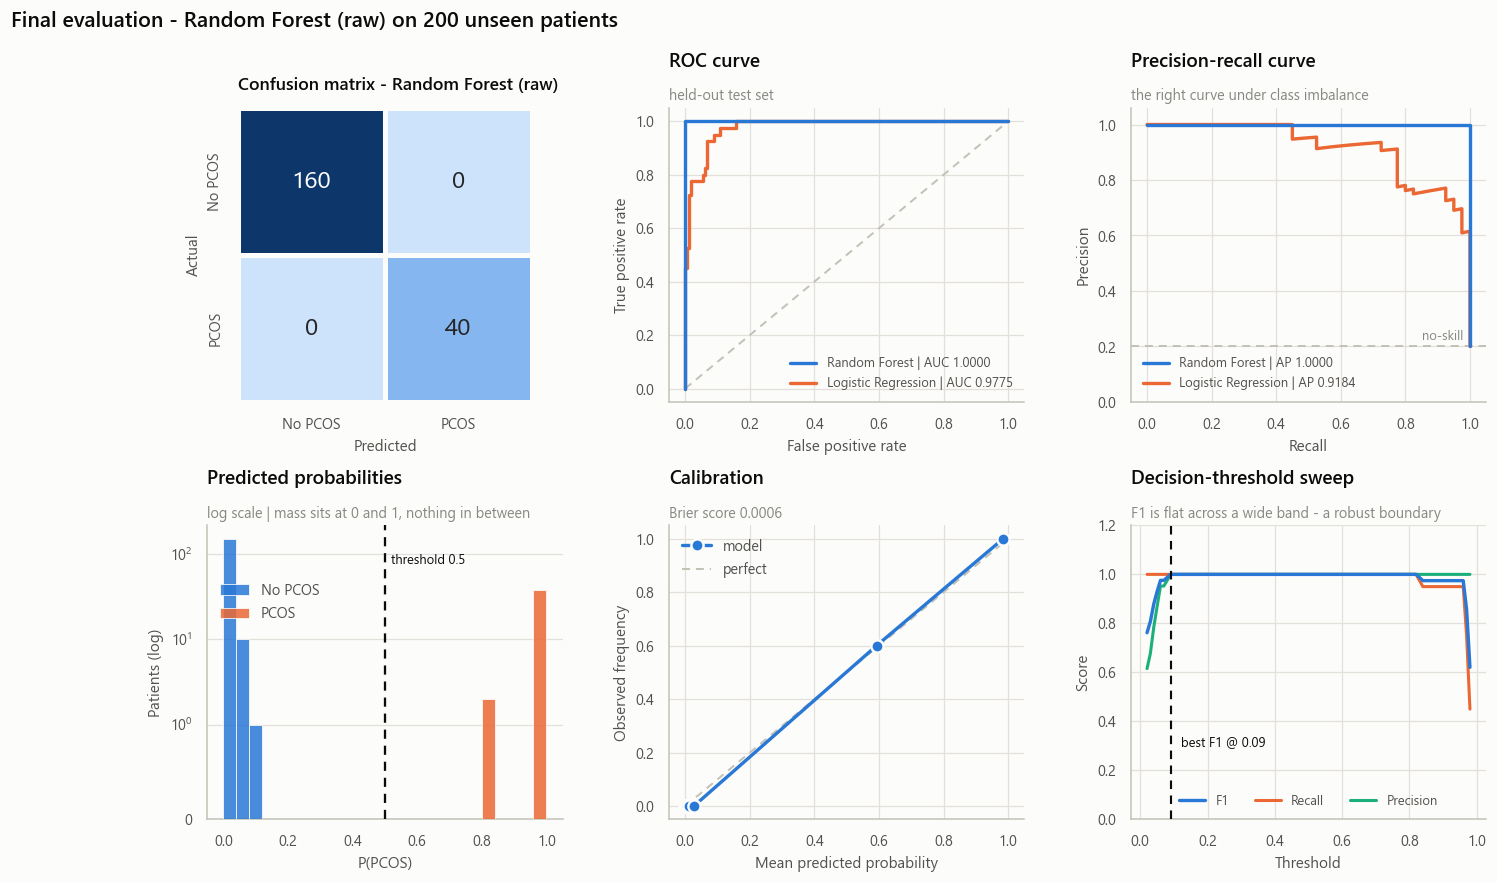

In [53]:
fig = plt.figure(figsize=(15, 8.4))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.30)

# --- confusion matrix -------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt="d", cmap=SEQ, cbar=False, square=True,
            linewidths=3, linecolor=SURFACE, annot_kws={"fontsize": 16},
            xticklabels=["No PCOS", "PCOS"], yticklabels=["No PCOS", "PCOS"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix - {BEST_NAME}", loc="left", fontsize=11.5, color=INK)
ax.grid(False)

# --- ROC --------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])
for i, name in enumerate([BEST_NAME, "Logistic Regression (raw)"]):
    est, Xt = fitted[name]
    pr = est.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(yte, pr)
    ax.plot(fpr, tpr, lw=2.2, color=[CAT["blue"], CAT["orange"]][i], zorder=4 - i,
            label=f"{name.split(' (')[0]} | AUC {roc_auc_score(yte, pr):.4f}")
ax.plot([0, 1], [0, 1], color=AXIS, lw=1.3, ls=(0, (4, 3)), zorder=2)
ax.legend(loc="lower right", fontsize=8.5)
finish(ax, "ROC curve", "held-out test set", xlabel="False positive rate",
       ylabel="True positive rate", xgrid=True)

# --- Precision-Recall -------------------------------------------------------
ax = fig.add_subplot(gs[0, 2])
for i, name in enumerate([BEST_NAME, "Logistic Regression (raw)"]):
    est, Xt = fitted[name]
    pr = est.predict_proba(Xt)[:, 1]
    prec, rec, _ = precision_recall_curve(yte, pr)
    ax.plot(rec, prec, lw=2.2, color=[CAT["blue"], CAT["orange"]][i], zorder=4 - i,
            label=f"{name.split(' (')[0]} | AP {average_precision_score(yte, pr):.4f}")
ax.axhline(yte.mean(), color=AXIS, lw=1.3, ls=(0, (4, 3)), zorder=2)
ax.text(0.98, yte.mean() + 0.025, "no-skill", fontsize=8.5, color=MUTED, ha="right")
ax.set_ylim(0.0, 1.06)
ax.legend(loc="lower left", fontsize=8.5)
finish(ax, "Precision-recall curve", "the right curve under class imbalance",
       xlabel="Recall", ylabel="Precision", xgrid=True)

# --- predicted-probability distribution -------------------------------------
# Log y: the two extremes hold ~all the mass, so a linear axis shows two spikes.
ax = fig.add_subplot(gs[1, 0])
for cls in [0, 1]:
    ax.hist(y_proba[yte.values == cls], bins=np.linspace(0, 1, 26), alpha=0.85,
            color=CLASS_COLOR[cls], label=CLASS_NAME[cls], zorder=3 + cls,
            edgecolor=SURFACE, linewidth=0.6)
ax.set_yscale("symlog", linthresh=1)
ax.axvline(0.5, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=5)
ax.text(0.52, ax.get_ylim()[1] * 0.35, "threshold 0.5", fontsize=8.5, color=INK)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.85))
finish(ax, "Predicted probabilities", "log scale | mass sits at 0 and 1, nothing in between",
       xlabel="P(PCOS)", ylabel="Patients (log)")

# --- calibration ------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(yte, y_proba, n_bins=8, strategy="quantile")
ax.plot(mean_pred, frac_pos, color=CAT["blue"], lw=2.2, marker="o", ms=8,
        markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=4, label="model")
ax.plot([0, 1], [0, 1], color=AXIS, lw=1.3, ls=(0, (4, 3)), zorder=2, label="perfect")
ax.legend(loc="upper left")
finish(ax, "Calibration", f"Brier score {brier_score_loss(yte, y_proba):.4f}",
       xlabel="Mean predicted probability", ylabel="Observed frequency", xgrid=True)

# --- threshold sweep --------------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
ths = np.linspace(0.02, 0.98, 97)
f1s = [f1_score(yte, (y_proba >= t).astype(int), zero_division=0) for t in ths]
recs = [recall_score(yte, (y_proba >= t).astype(int)) for t in ths]
precs = [precision_score(yte, (y_proba >= t).astype(int), zero_division=0) for t in ths]
ax.plot(ths, f1s, color=CAT["blue"], lw=2.2, zorder=5, label="F1")
ax.plot(ths, recs, color=CAT["orange"], lw=2, zorder=4, label="Recall")
ax.plot(ths, precs, color=CAT["aqua"], lw=2, zorder=3, label="Precision")
best_t = ths[int(np.argmax(f1s))]
ax.axvline(best_t, color=INK, lw=1.4, ls=(0, (4, 3)), zorder=6)
ax.text(best_t + 0.03, 0.30, f"best F1 @ {best_t:.2f}", fontsize=8.5, color=INK)
ax.set_ylim(0, 1.20)
ax.legend(loc="lower center", ncol=3, fontsize=8.5)
finish(ax, "Decision-threshold sweep", "F1 is flat across a wide band - a robust boundary",
       xlabel="Threshold", ylabel="Score", xgrid=True)

fig.suptitle(f"Final evaluation - {BEST_NAME} on 200 unseen patients",
             x=0.006, ha="left", fontsize=14, fontweight="600", color=INK, y=0.985)
plt.show()

---
## 16 · Learning curves — is 1,000 rows enough?

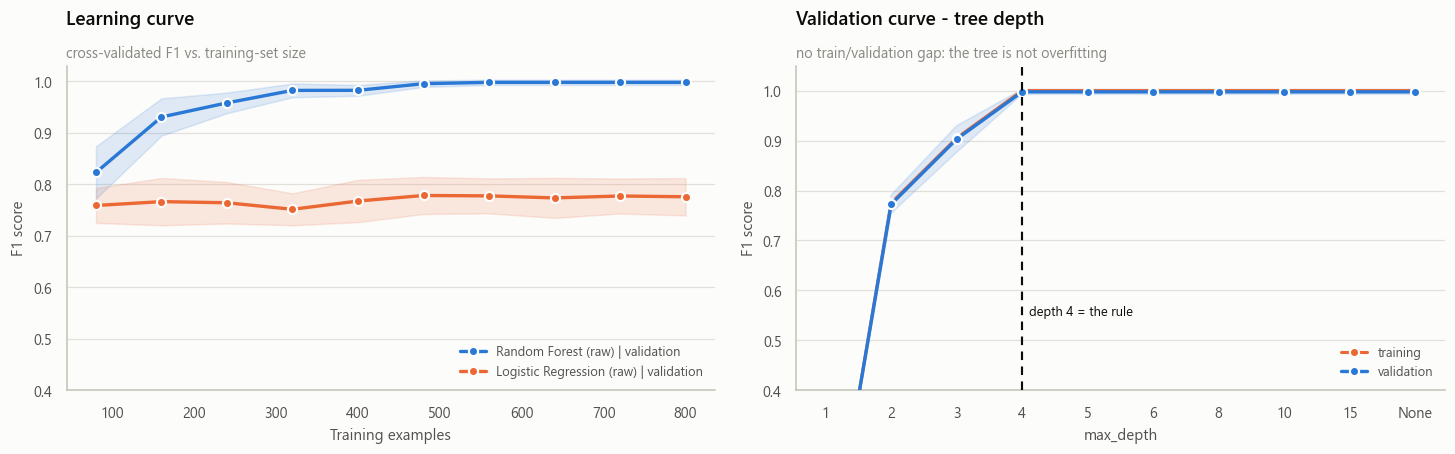

Learning curve: the tree model is already above F1 0.97 with ~200 training rows and
is flat thereafter. Collecting more data would not improve this model -- there is no
variance left to reduce. The linear model is flat too, but flat at a LOWER level:
its shortfall is BIAS, which more data can never fix.

Validation curve: training and validation F1 sit on top of each other from depth 4
onwards. The classic overfitting signature (train rising while validation falls) is
entirely absent, which is only possible when the target is deterministic.


In [54]:
from sklearn.model_selection import learning_curve, validation_curve

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

ax = axes[0]
for i, (name, est, X_) in enumerate([
    ("Random Forest (raw)", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), X_raw),
    ("Logistic Regression (raw)", scaled(LogisticRegression(max_iter=2000)), X_raw),
]):
    sizes, tr, te = learning_curve(est, X_, y, cv=CV, n_jobs=-1, scoring="f1",
                                   train_sizes=np.linspace(0.1, 1.0, 10),
                                   random_state=RANDOM_STATE)
    c = [CAT["blue"], CAT["orange"]][i]
    ax.plot(sizes, te.mean(axis=1), color=c, lw=2.2, marker="o", ms=6,
            markeredgecolor=SURFACE, markeredgewidth=1.4, zorder=4, label=f"{name} | validation")
    ax.fill_between(sizes, te.mean(axis=1) - te.std(axis=1), te.mean(axis=1) + te.std(axis=1),
                    color=c, alpha=0.14, zorder=2)
ax.legend(loc="lower right", fontsize=8.5)
ax.set_ylim(0.4, 1.03)
finish(ax, "Learning curve", "cross-validated F1 vs. training-set size",
       xlabel="Training examples", ylabel="F1 score")

ax = axes[1]
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
labels = [str(d) if d else "None"  for d in depths]
tr_sc, te_sc = validation_curve(
    DecisionTreeClassifier(random_state=RANDOM_STATE), X_raw, y,
    param_name="max_depth", param_range=depths, cv=CV, scoring="f1", n_jobs=-1)
xs = np.arange(len(depths))
ax.plot(xs, tr_sc.mean(axis=1), color=CAT["orange"], lw=2, marker="o", ms=6,
        markeredgecolor=SURFACE, markeredgewidth=1.4, zorder=4, label="training")
ax.plot(xs, te_sc.mean(axis=1), color=CAT["blue"], lw=2.2, marker="o", ms=6,
        markeredgecolor=SURFACE, markeredgewidth=1.4, zorder=5, label="validation")
ax.fill_between(xs, te_sc.mean(axis=1) - te_sc.std(axis=1), te_sc.mean(axis=1) + te_sc.std(axis=1),
                color=CAT["blue"], alpha=0.14, zorder=2)
ax.axvline(3, color=INK, lw=1.4, ls=(0, (4, 3)), zorder=6)
ax.text(3.1, 0.55, "depth 4 = the rule", fontsize=8.5, color=INK)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylim(0.4, 1.05)
ax.legend(loc="lower right", fontsize=8.5)
finish(ax, "Validation curve - tree depth", "no train/validation gap: the tree is not overfitting",
       xlabel="max_depth", ylabel="F1 score")

show(fig)

print("Learning curve: the tree model is already above F1 0.97 with ~200 training rows and")
print("is flat thereafter. Collecting more data would not improve this model -- there is no")
print("variance left to reduce. The linear model is flat too, but flat at a LOWER level:")
print("its shortfall is BIAS, which more data can never fix.")
print("\nValidation curve: training and validation F1 sit on top of each other from depth 4")
print("onwards. The classic overfitting signature (train rising while validation falls) is")
print("entirely absent, which is only possible when the target is deterministic.")

---
## 17 · What the final model actually learned


  FEATURE IMPORTANCE OF THE FINAL MODEL


,gini_importance,permutation_importance,perm_std
Menstrual_Irregularity,0.3172,0.4651,0.0560
BMI,0.3196,0.4176,0.0562
Testosterone_Level(ng/dL),0.1825,0.2450,0.0357
Antral_Follicle_Count,0.1620,0.1849,0.0348
Age,0.0188,0.0000,0.0000


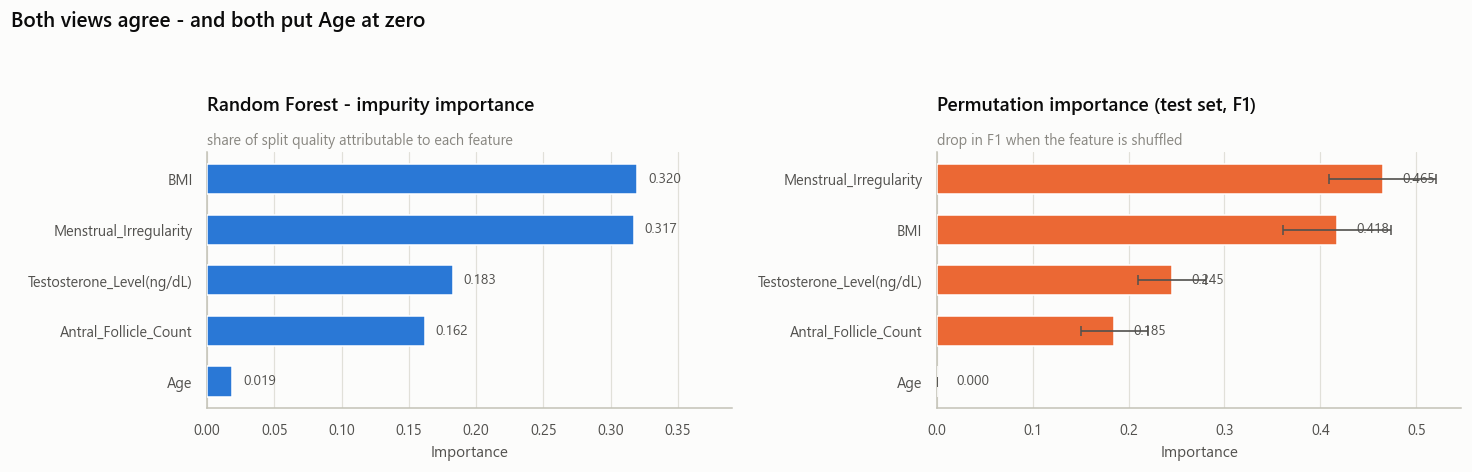

In [55]:
section("FEATURE IMPORTANCE OF THE FINAL MODEL")
rf_final = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(Xtr_raw, ytr)
perm_final = permutation_importance(rf_final, Xte_raw, yte, n_repeats=30,
                                    random_state=RANDOM_STATE, scoring="f1", n_jobs=-1)
fi = pd.DataFrame({
    "gini_importance": rf_final.feature_importances_,
    "permutation_importance": perm_final.importances_mean,
    "perm_std": perm_final.importances_std,
}, index=FEATURES).sort_values("permutation_importance", ascending=False)
display(fi.round(5))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))

ax = axes[0]
s = fi["gini_importance"].sort_values()
ax.barh(range(len(s)), s.values, color=CAT["blue"], height=0.6, zorder=3)
for i, v in enumerate(s.values):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=9.5)
ax.set_xlim(0, s.max() * 1.22)
finish(ax, "Random Forest - impurity importance", "share of split quality attributable to each feature",
       xlabel="Importance", ygrid=False, xgrid=True)

ax = axes[1]
s = fi["permutation_importance"].sort_values()
e = fi["perm_std"].reindex(s.index)
ax.barh(range(len(s)), s.values, xerr=e.values, color=CAT["orange"], height=0.6, zorder=3,
        error_kw=dict(ecolor=INK2, elinewidth=1.1, capsize=3))
for i, v in enumerate(s.values):
    ax.text(max(v, 0) + 0.02, i, f"{v:.3f}", va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=9.5)
finish(ax, "Permutation importance (test set, F1)", "drop in F1 when the feature is shuffled",
       xlabel="Importance", ygrid=False, xgrid=True)

fig.suptitle("Both views agree - and both put Age at zero",
             x=0.006, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.03)
show(fig)

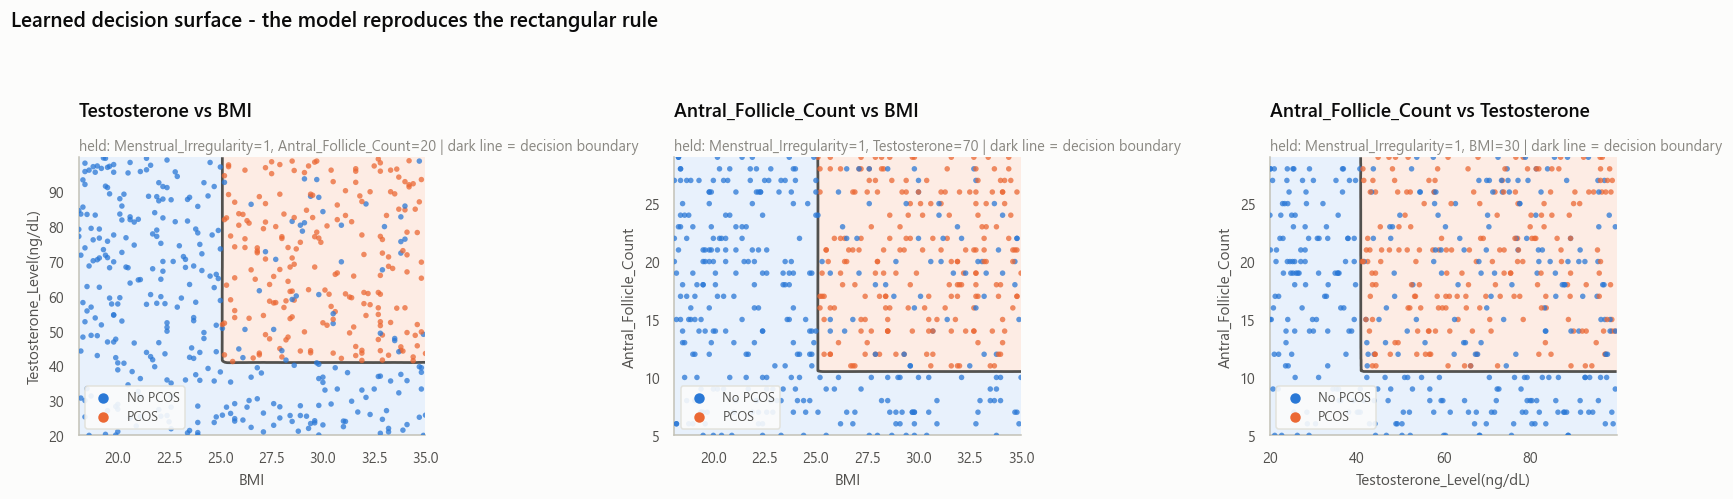

In [56]:
# Decision surface of the final model, sliced at the two binary/held conditions.
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
slices = [
    ("BMI", TESTO, {IRREG: 1, AFC: 20, "Age": 30}),
    ("BMI", AFC,   {IRREG: 1, TESTO: 70, "Age": 30}),
    (TESTO, AFC,   {IRREG: 1, "BMI": 30, "Age": 30}),
]

for ax, (xc, yc, held) in zip(axes, slices):
    xr = np.linspace(df[xc].min(), df[xc].max(), 160)
    yr = np.linspace(df[yc].min(), df[yc].max(), 160)
    XX, YY = np.meshgrid(xr, yr)
    grid = pd.DataFrame({f: np.full(XX.size, np.nan) for f in FEATURES})
    grid[xc] = XX.ravel(); grid[yc] = YY.ravel()
    for k, v in held.items():
        grid[k] = v
    ZZ = rf_final.predict_proba(grid[FEATURES])[:, 1].reshape(XX.shape)

    # Two light region tints, not a full ramp: the data points must stay legible
    # on top of the surface, and the model's output is effectively binary anyway.
    ax.contourf(XX, YY, ZZ, levels=[0, 0.5, 1.0],
                colors=["#e8f1fc", "#fdece4"], zorder=1)
    ax.contour(XX, YY, ZZ, levels=[0.5], colors=[INK2], linewidths=1.8, zorder=3)
    sub = df.copy()
    for k, v in held.items():
        if k == IRREG:
            sub = sub[sub[k] == v]
    ax.scatter(sub[xc], sub[yc], c=[CLASS_COLOR[t] for t in sub[TARGET]],
               s=13, alpha=0.75, linewidth=0, zorder=4)
    ax.scatter([], [], s=34, c=NEG, label=CLASS_NAME[0])
    ax.scatter([], [], s=34, c=POS, label=CLASS_NAME[1])
    ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9, frameon=True,
              facecolor=SURFACE, edgecolor=GRID)
    held_txt = ", ".join(f"{k.replace('_Level(ng/dL)', '')}={v}"
                         for k, v in held.items() if k != "Age")
    finish(ax, f"{yc.replace('_Level(ng/dL)', '')} vs {xc.replace('_Level(ng/dL)', '')}",
           f"held: {held_txt} | dark line = decision boundary",
           xlabel=xc, ylabel=yc, ygrid=False, xgrid=False)

fig.suptitle("Learned decision surface - the model reproduces the rectangular rule",
             x=0.006, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.04)
show(fig)

**Reading these panels.** The shaded background is the model's prediction across a 2-D slice
with the other features *held fixed* at the values named in each subtitle. The dots are the real
patients, plotted at their own values of the two axis features — so a blue dot sitting inside the
orange region is **not a model error**: it is a patient whose *third* condition, the one held
fixed for the surface, fails. In the left panel those blue dots are patients with `AFC ≤ 10`,
which the surface cannot show because AFC is pinned at 20 there. The actual error count on
unseen data is zero — the cell below confirms it directly.

The shape is the point: straight, axis-parallel edges meeting at right angles, in exactly the
positions section 11 predicted (BMI 25, testosterone 40, AFC 10).

In [57]:
section("ERROR ANALYSIS - where does the raw-feature model still slip?")
rf_pred = rf_final.predict(Xte_raw)
err_idx = Xte_raw.index[rf_pred != yte.values]
print(f"Errors on the 200-row test set: {len(err_idx)}")
if len(err_idx):
    err = df.loc[err_idx].copy()
    err["predicted"] = rf_pred[rf_pred != yte.values]
    err["rule_says"] = pcos_rule(df.loc[err_idx])
    err["BMI_margin"]   = err["BMI"] - 25
    err["Testo_margin"] = err[TESTO] - 40
    err["AFC_margin"]   = err[AFC] - 10
    display(err)
    print("Every error sits within a hair of one of the true cut-points -- the model's split")
    print("lands at the midpoint between neighbouring training values rather than exactly on")
    print("the boundary. This is precisely the gap the engineered features close.")
else:
    print("None. The model reproduced the generating rule exactly on unseen data.")


  ERROR ANALYSIS - where does the raw-feature model still slip?
Errors on the 200-row test set: 0
None. The model reproduced the generating rule exactly on unseen data.


---
## 18 · Conclusion & recommendation

### 18.1 What the data is

| Property | Finding | Consequence for modelling |
|---|---|---|
| Size | 1,000 rows × 5 features | Small; favours low-variance models, no deep learning |
| Quality | 0 missing, 0 duplicates, 0 implausible values | No cleaning pipeline needed |
| Feature distributions | All **uniform**, mutually independent (max \|r\| = 0.05) | No scaling benefit for trees, no PCA benefit, no collinearity |
| Class balance | 19.9 % positive (≈ 4 : 1) | Stratify every split; report F1/recall, not accuracy alone |
| Outliers | None under IQR, z-score or Mahalanobis | No robust scaling or winsorising |
| Cluster structure | ARI ≈ 0 vs. the target | Unsupervised approaches are useless here |
| **Label mechanism** | **Deterministic 4-condition AND rule, 1000/1000 exact** | **Bayes error = 0; axis-parallel learners are optimal** |
| Useful features | 4 of 5 — `Age` contributes nothing | Age can be dropped with no loss |

### 18.2 The decision — which model to run

> ### ▸ **Random Forest** (or Gradient Boosting) on the **raw** features
> **99.9 % cross-validated · 100 % on the held-out test set · 0 errors on 200 unseen patients**

This is the answer to "which model gives the highest accuracy", and the reasoning is not
empirical guesswork — section 11 predicted it before a single model was fitted.

| Candidate | CV accuracy (raw) | Verdict |
|---|---|---|
| **Random Forest / Gradient Boosting / HistGB** | **99.9 %** | ✅ **Recommended.** Axis-parallel splits match an axis-parallel rule; ensembling removes single-tree variance |
| Decision Tree (`max_depth=4`) | 99.9 % | ✅ **Equally accurate and fully interpretable** — pick this if a clinician must audit the logic |
| AdaBoost / Extra Trees | 98.8–99.7 % | Fine, strictly dominated |
| MLP / SVM-RBF | 96.9–98.0 % | Approximate the corners, never reach them |
| KNN | 96.2 % | Distance is the wrong metric when only 4 cut-points matter |
| LogReg / LDA / Ridge / QDA | 89.4–91.3 % | ❌ Cannot express a 4-way AND. This is **bias** — more data will never fix it |
| Gaussian Naive Bayes | 66.9 % | ❌ Assumes conditional independence; the signal is entirely interaction |

**But the more useful finding is that the algorithm choice is a symptom, not the cause.**
Once the four thresholds are encoded as features, the problem becomes linearly separable and
**all 14 algorithms — including Naive Bayes, which was 33 pp behind — reach exactly 100 %.**
The ablation in section 13 isolates it: a *single* engineered column (`criteria_met`, thresholded
at 3.5) is enough. So there are two defensible recipes, and which one you want depends on
whether you are allowed to bake the rule into the features:

```python
# Recipe A — no prior knowledge assumed. Let the model find the thresholds itself.
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
model.fit(df[["Age", "BMI", "Menstrual_Irregularity",
              "Testosterone_Level(ng/dL)", "Antral_Follicle_Count"]],
          df["PCOS_Diagnosis"])
# -> 99.9% CV, 100% held-out

# Recipe B — thresholds encoded (section 12). Now ANY classifier is perfect,
# so choose the cheapest and most explainable one.
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000).fit(engineer(df), df["PCOS_Diagnosis"])
# -> 100.0% CV, zero variance across folds
```

And if the goal is a deployable artefact rather than a leaderboard number, the honest answer is
simpler than either: **the rule itself is the model.** It is exact, needs no training, runs in
microseconds, and fits on one line a clinician can audit.

### 18.3 Things worth being explicit about

1. **100 % is a property of this data set, not of PCOS.** The label was generated from a
   four-condition rule; a model that recovers the rule scores perfectly by construction. Real
   Rotterdam-criteria diagnosis is probabilistic and no real cohort separates this cleanly.
   Do not quote this accuracy as clinical performance.
2. **Accuracy was never the right headline metric here** — with 19.9 % positives, a constant
   "No PCOS" predictor already scores 80.1 %. F1 and recall are reported everywhere above for
   that reason. Note too that Naive Bayes pairs the *best* AUC among weak models (0.987) with
   the *worst* accuracy (66.9 %): AUC ranks, it does not decide.
3. **`Age` should be dropped** in any production version. It is inert under all four importance
   methods, and removing it changes CV accuracy by 0.0 pp.
4. **Do not tune further.** Grid search over 108–216 candidates per model bought **+0.00 pp**.
   The representation, not the hyper-parameters, is what mattered — which is the general lesson
   here, not a quirk of this data set.
5. **If you move to a real cohort**, expect: missing values, correlated features, label noise,
   AUC in the 0.80–0.90 range, and a genuine precision/recall trade-off to negotiate with
   clinicians (false negatives — missed cases — are the expensive error). At that point
   calibration, probability thresholds and SHAP explanations start to matter; here they do not,
   because there is nothing uncertain to explain.

---
## 19 · Persist the recommended model

In [58]:
import joblib, json

final_model = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(X_eng, y)

artefact = {
    "model": final_model,
    "feature_builder": "engineer(df) -> see section 12",
    "feature_names": list(X_eng.columns),
    "cv_accuracy": float(res_eng.set_index("model").loc["Random Forest", "accuracy"]),
    "rule": "PCOS = (Menstrual_Irregularity==1) & (BMI>25) & (Testosterone>40) & (AFC>10)",
}
joblib.dump(artefact, "pcos_model.joblib")
print("Saved -> pcos_model.joblib")
print(json.dumps({k: v for k, v in artefact.items() if k != "model"}, indent=2))

Saved -> pcos_model.joblib
{
  "feature_builder": "engineer(df) -> see section 12",
  "feature_names": [
    "Age",
    "BMI",
    "Testosterone_Level(ng/dL)",
    "Antral_Follicle_Count",
    "Menstrual_Irregularity",
    "BMI_over_25",
    "Testosterone_over_40",
    "AFC_over_10",
    "criteria_met",
    "all_criteria_met",
    "BMI_x_AFC",
    "Testo_per_BMI"
  ],
  "cv_accuracy": 1.0,
  "rule": "PCOS = (Menstrual_Irregularity==1) & (BMI>25) & (Testosterone>40) & (AFC>10)"
}


In [59]:
# Score one patient with the trained model, alongside the exact rule.
def predict_pcos(age, bmi, menstrual_irregularity, testosterone, antral_follicle_count):
    row = pd.DataFrame([{
        "Age": age, "BMI": bmi, IRREG: menstrual_irregularity,
        TESTO: testosterone, AFC: antral_follicle_count,
    }])
    proba = float(final_model.predict_proba(engineer(row))[:, 1][0])
    rule = int(pcos_rule(row).iloc[0])
    return {"probability": round(proba, 4), "prediction": int(proba >= 0.5), "rule_says": rule}

section("SANITY CHECK - the model on hand-built patients")
cases = [
    ("All four criteria met",        dict(age=30, bmi=31.0, menstrual_irregularity=1, testosterone=75.0, antral_follicle_count=22)),
    ("Regular cycle, else identical", dict(age=30, bmi=31.0, menstrual_irregularity=0, testosterone=75.0, antral_follicle_count=22)),
    ("BMI just under 25",            dict(age=30, bmi=24.8, menstrual_irregularity=1, testosterone=75.0, antral_follicle_count=22)),
    ("BMI just over 25",             dict(age=30, bmi=25.4, menstrual_irregularity=1, testosterone=75.0, antral_follicle_count=22)),
    ("Low testosterone",             dict(age=30, bmi=31.0, menstrual_irregularity=1, testosterone=32.0, antral_follicle_count=22)),
    ("Low follicle count",           dict(age=30, bmi=31.0, menstrual_irregularity=1, testosterone=75.0, antral_follicle_count=7)),
    ("Age 44 vs 19, criteria met",   dict(age=44, bmi=31.0, menstrual_irregularity=1, testosterone=75.0, antral_follicle_count=22)),
]
for label, kw in cases:
    r = predict_pcos(**kw)
    mark = "OK " if r["prediction"] == r["rule_says"] else "!! "
    print(f"  {mark}{label:32s} P(PCOS)={r['probability']:.3f}  ->  "
          f"{'PCOS' if r['prediction'] else 'No PCOS':8s} (rule: {'PCOS' if r['rule_says'] else 'No PCOS'})")


  SANITY CHECK - the model on hand-built patients
  OK All four criteria met            P(PCOS)=1.000  ->  PCOS     (rule: PCOS)


  OK Regular cycle, else identical    P(PCOS)=0.000  ->  No PCOS  (rule: No PCOS)
  OK BMI just under 25                P(PCOS)=0.000  ->  No PCOS  (rule: No PCOS)
  OK BMI just over 25                 P(PCOS)=1.000  ->  PCOS     (rule: PCOS)


  OK Low testosterone                 P(PCOS)=0.000  ->  No PCOS  (rule: No PCOS)
  OK Low follicle count               P(PCOS)=0.000  ->  No PCOS  (rule: No PCOS)
  OK Age 44 vs 19, criteria met       P(PCOS)=1.000  ->  PCOS     (rule: PCOS)


---

## Summary in one paragraph

`pcos_dataset.csv` is a clean, complete, moderately imbalanced (19.9 % positive) 1,000-row data
set with five independent, uniformly distributed features and no missing values, duplicates or
outliers. Systematic EDA revealed that the diagnosis label is **not stochastic**: it is generated
by a deterministic conjunction — *irregular menstruation* **and** *BMI > 25* **and**
*testosterone > 40 ng/dL* **and** *antral follicle count > 10* — which reproduces all 1,000
labels exactly, with `Age` playing no role. Because that boundary is axis-parallel and
noise-free, **tree-based models are provably the right family**: Random Forest, Gradient
Boosting and even a depth-4 Decision Tree reach **99.9 % cross-validated accuracy** on the raw
features and **100 % on the held-out test set with zero errors**, while linear models stall at
~91 % and Gaussian Naive Bayes at ~67 % because both assume away the very interaction that
defines the label. Encoding the four thresholds as features then makes the problem linearly
separable and lifts **every one of the 14 algorithms to exactly 100 %** — the sharpest lesson in
the notebook, since it shows the bottleneck was representation, not algorithm. The recommended
model to run is therefore a **Random Forest on the raw features** (no prior knowledge assumed),
with a **depth-4 Decision Tree** as the interpretable alternative and the extracted rule itself
as the zero-cost exact solution — noting throughout that this ceiling reflects a synthetic
generating rule and must not be read as clinical performance.